In [141]:
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pymc as pm
import arviz as az
from scipy.special import expit

%matplotlib inline
%config InlineBackend.figure_format = "retina"

sns.set(rc={"figure.figsize" : (25, 15)})
sns.set(font_scale=2)
sns.set_style("ticks")

In [142]:
df = pandas.read_csv(
    "https://docs.google.com/spreadsheets/d/1AZfxs2caMVdYPsiqiZJmX3P-CTq5Yewi3CAccvT7acw/export?format=csv",
    parse_dates=["end_date"])
df = df[df["pollster"].notnull()].copy()
del df["url"]

df = df.melt(
    id_vars=["pollster", "end_date", "population", "mode", "sample_size", "moe", "kind", "partisan", "Weight"],
    var_name="candidate", value_name="pct")
# df = df[df["pct"].notnull()].copy()

In [143]:
df

,pollster,end_date,population,mode,sample_size,moe,kind,partisan,Weight,candidate,pct
0,Fairleigh Dickinson,2023-03-06,vap,phone/text-to-web,808.0,4.60,favourability,0,0.75,Baraka,6.0
1,GQR,2024-03-12,lv,voterfile,603.0,4.00,favourability,Sherrill,0.50,Baraka,32.0
2,GQR,2024-04-12,lv,voterfile,603.0,4.00,horse,Sherrill,0.50,Baraka,20.0
3,Renaissance Campaign Strategies,2024-07-14,lv,unknown,902.0,3.46,horse,Baraka,0.50,Baraka,12.0
4,Renaissance Campaign Strategies,2024-07-14,lv,unknown,902.0,3.46,favourability,Baraka,0.50,Baraka,31.0
...,...,...,...,...,...,...,...,...,...,...,...
107,MDW Communications,2025-02-10,lv,text-to-web,789.0,3.00,horse,Baraka,0.50,Undecided,52.1
108,MDW Communications,2025-02-10,lv,text-to-web,789.0,3.00,favourability,Baraka,0.50,Undecided,0.0
109,Fairleigh Dickinson,2025-02-28,rv,phone/text-to-web,572.0,4.50,favourability,0,0.75,Undecided,0.0
110,GBAO,2025-03-03,lv,unknown,800.0,3.50,horse,Spiller,0.50,Undecided,24.0


In [144]:
df["pct_lower"] = df["pct"] - df["moe"]
df["pct_upper"] = df["pct"] + df["moe"]
df["pct_lower"] = df["pct_lower"].apply(lambda x : 0 if x < 0 else x)

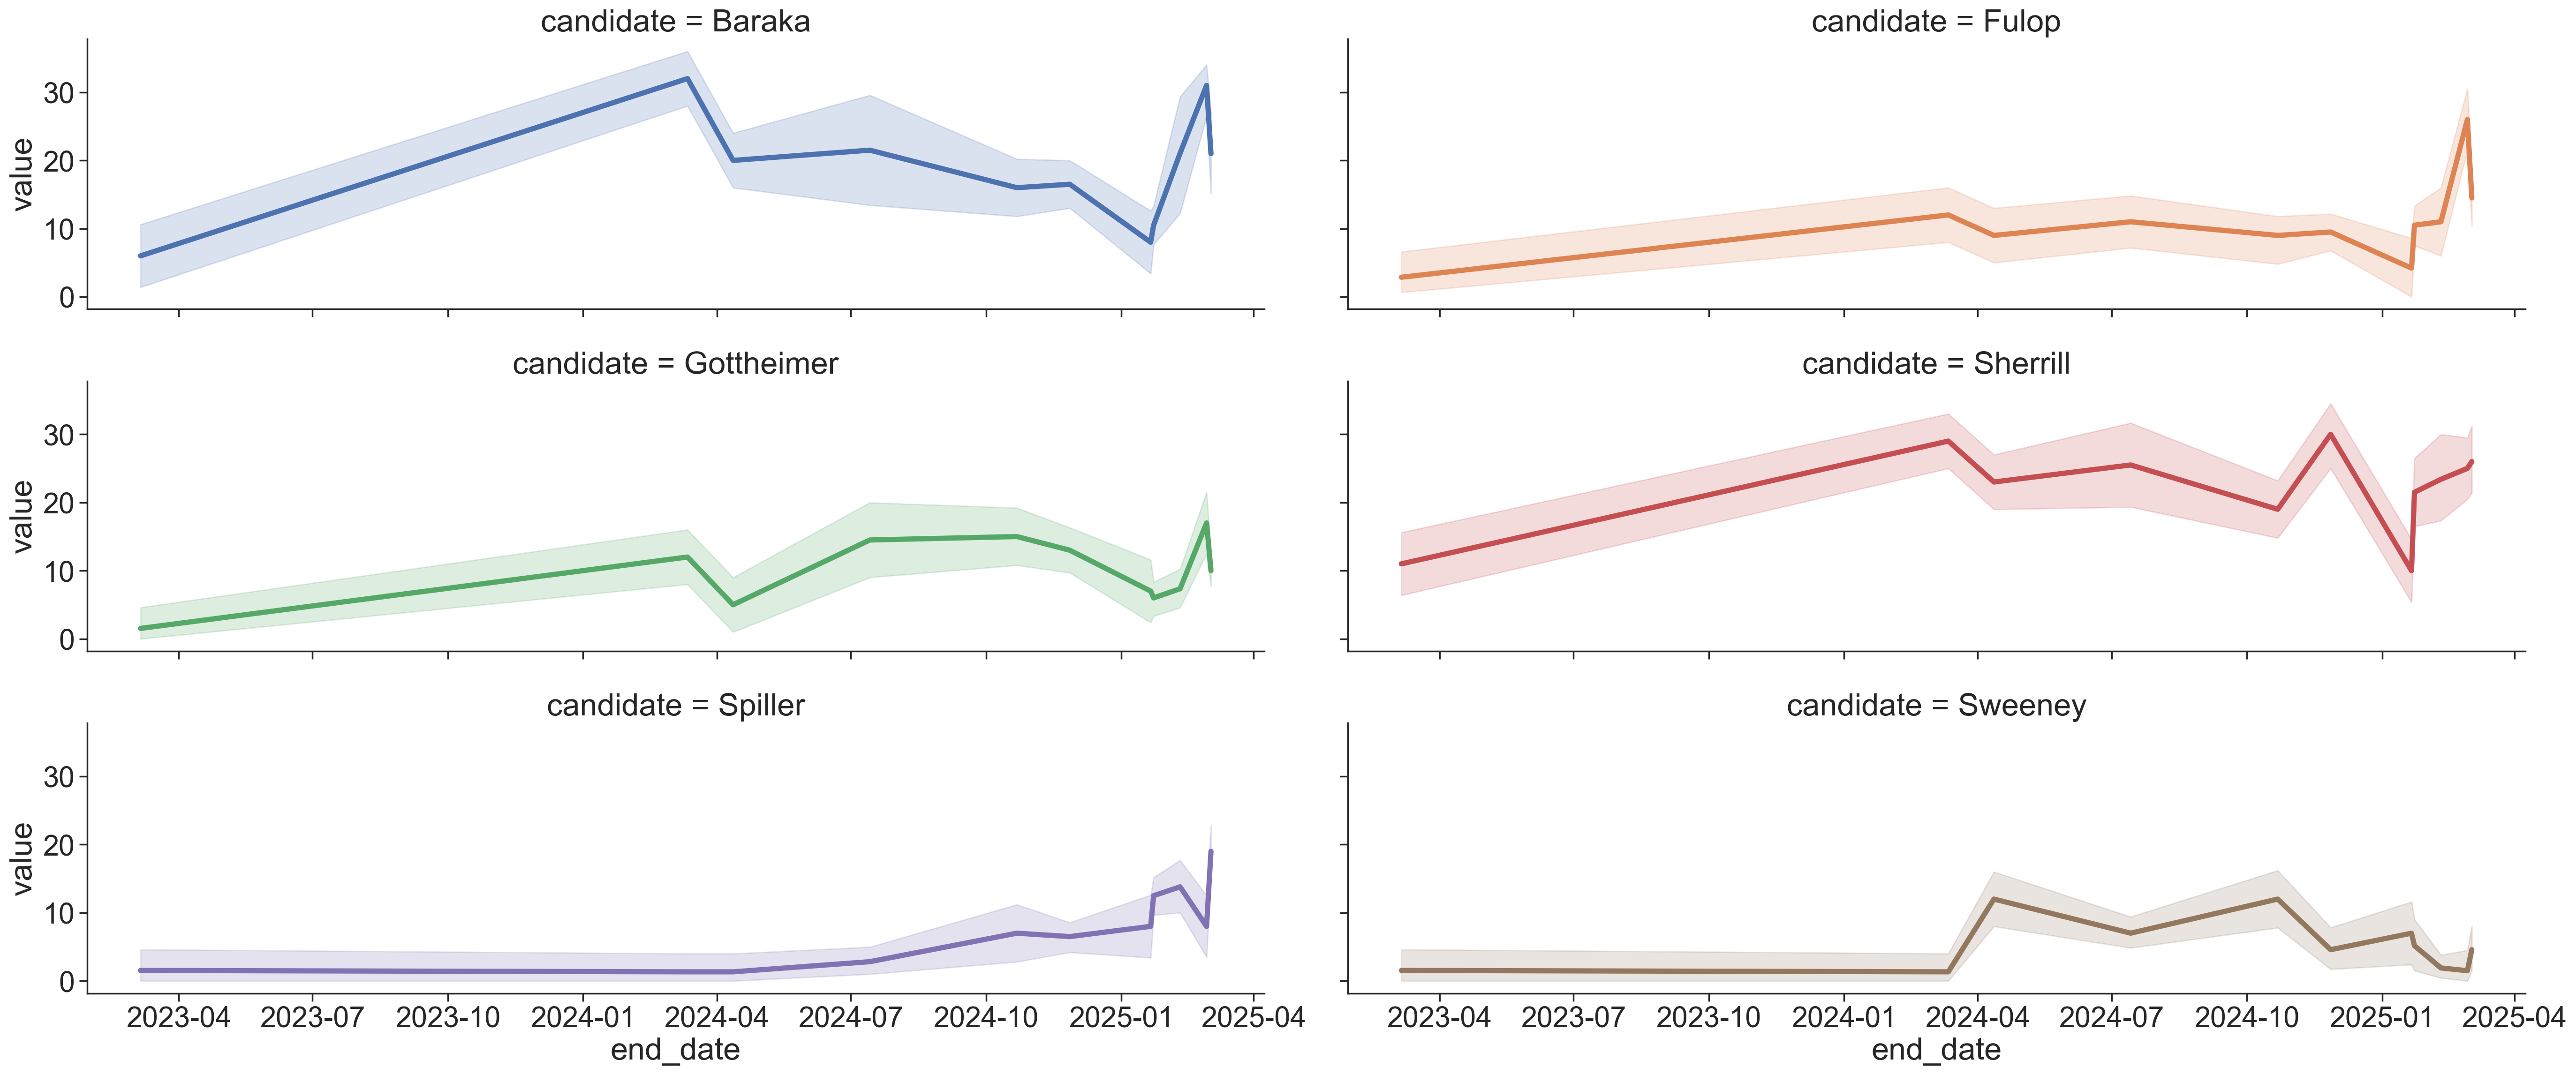

In [145]:
for_plot = df[["end_date", "candidate", "partisan", "pct", "pct_lower", "pct_upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "candidate", "partisan"])

ax = sns.relplot(data=for_plot[for_plot["candidate"] != "Undecided"], x="end_date", y="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="line", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

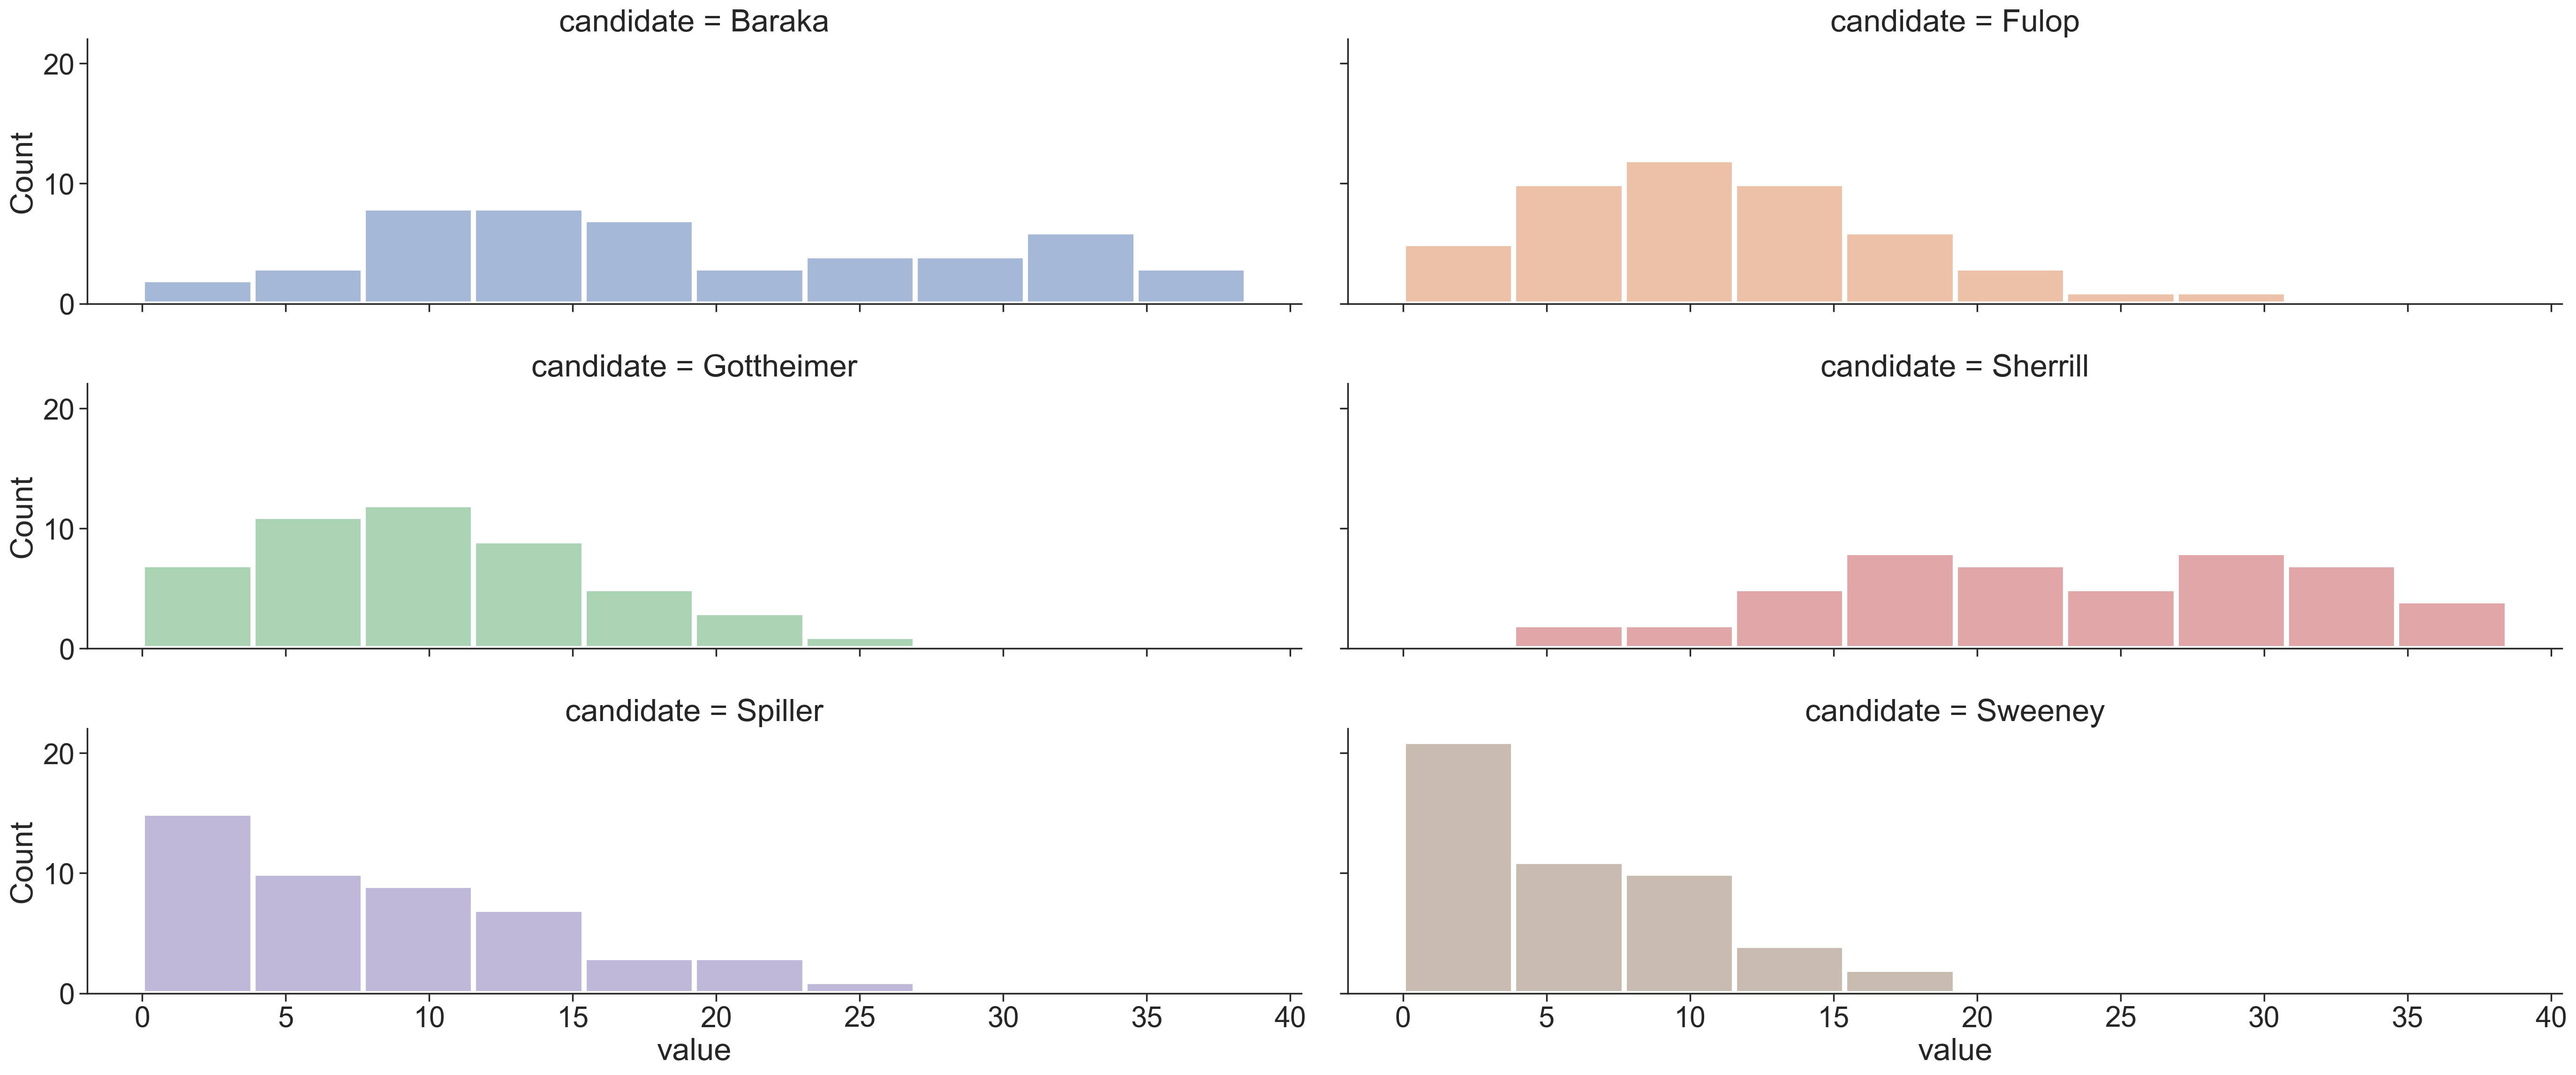

In [146]:
ax = sns.displot(data=for_plot[for_plot["candidate"] != "Undecided"], x="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="hist", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

In [147]:
(for_plot.groupby(["candidate", "partisan"]).agg({"value" : "mean"}).reset_index()
 .pivot(index="candidate", columns="partisan", values="value"))

partisan,0,Baraka,Sherrill,Spiller
candidate,,,,
Baraka,15.250000,21.275000,21.250000,15.750000
Fulop,10.516667,11.000000,10.000000,12.500000
Gottheimer,10.133333,10.925000,10.750000,8.000000
Sherrill,16.250000,24.450000,28.000000,23.750000
Spiller,6.133333,8.310000,3.916667,15.750000
Sweeney,5.508333,4.450000,5.621667,4.875000
Undecided,40.125000,27.313333,21.750000,23.541667


In [148]:
df["num_for"] = ((df["pct"] / 100) * df["sample_size"]).round(0)
df["num_for_lower"] = ((df["pct_lower"] / 100) * df["sample_size"]).round(0)
df["num_for_upper"] = ((df["pct_upper"] / 100) * df["sample_size"]).round(0)

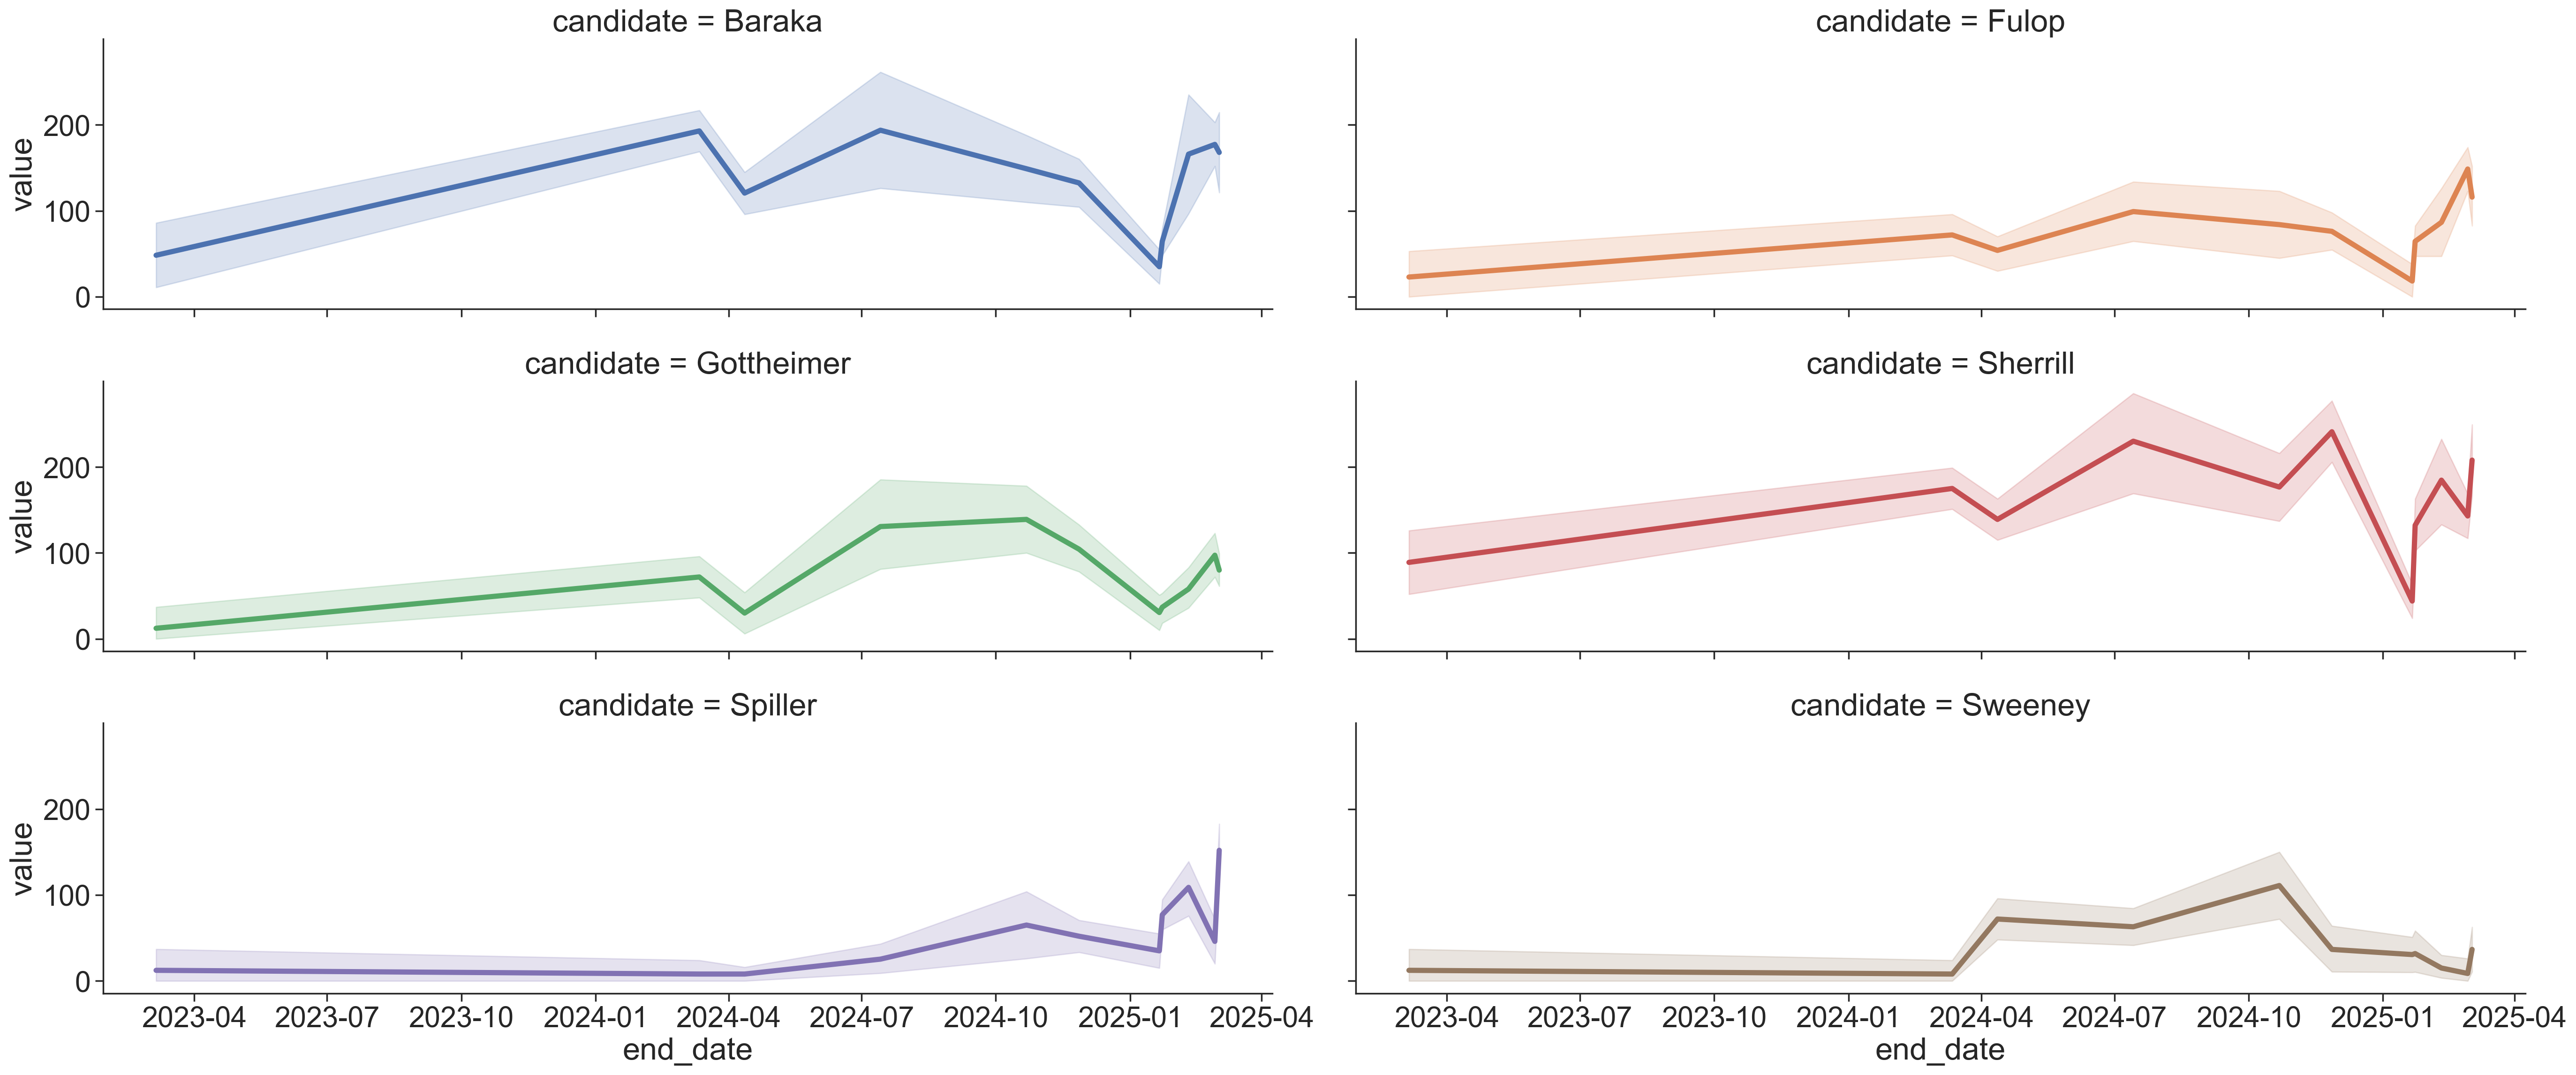

In [149]:
for_plot = df[["end_date", "candidate", "num_for", "num_for_lower", "num_for_upper"]].copy()
for_plot = for_plot.melt(id_vars=["end_date", "candidate"])

ax = sns.relplot(data=for_plot[for_plot["candidate"] != "Undecided"], x="end_date", y="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="line", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

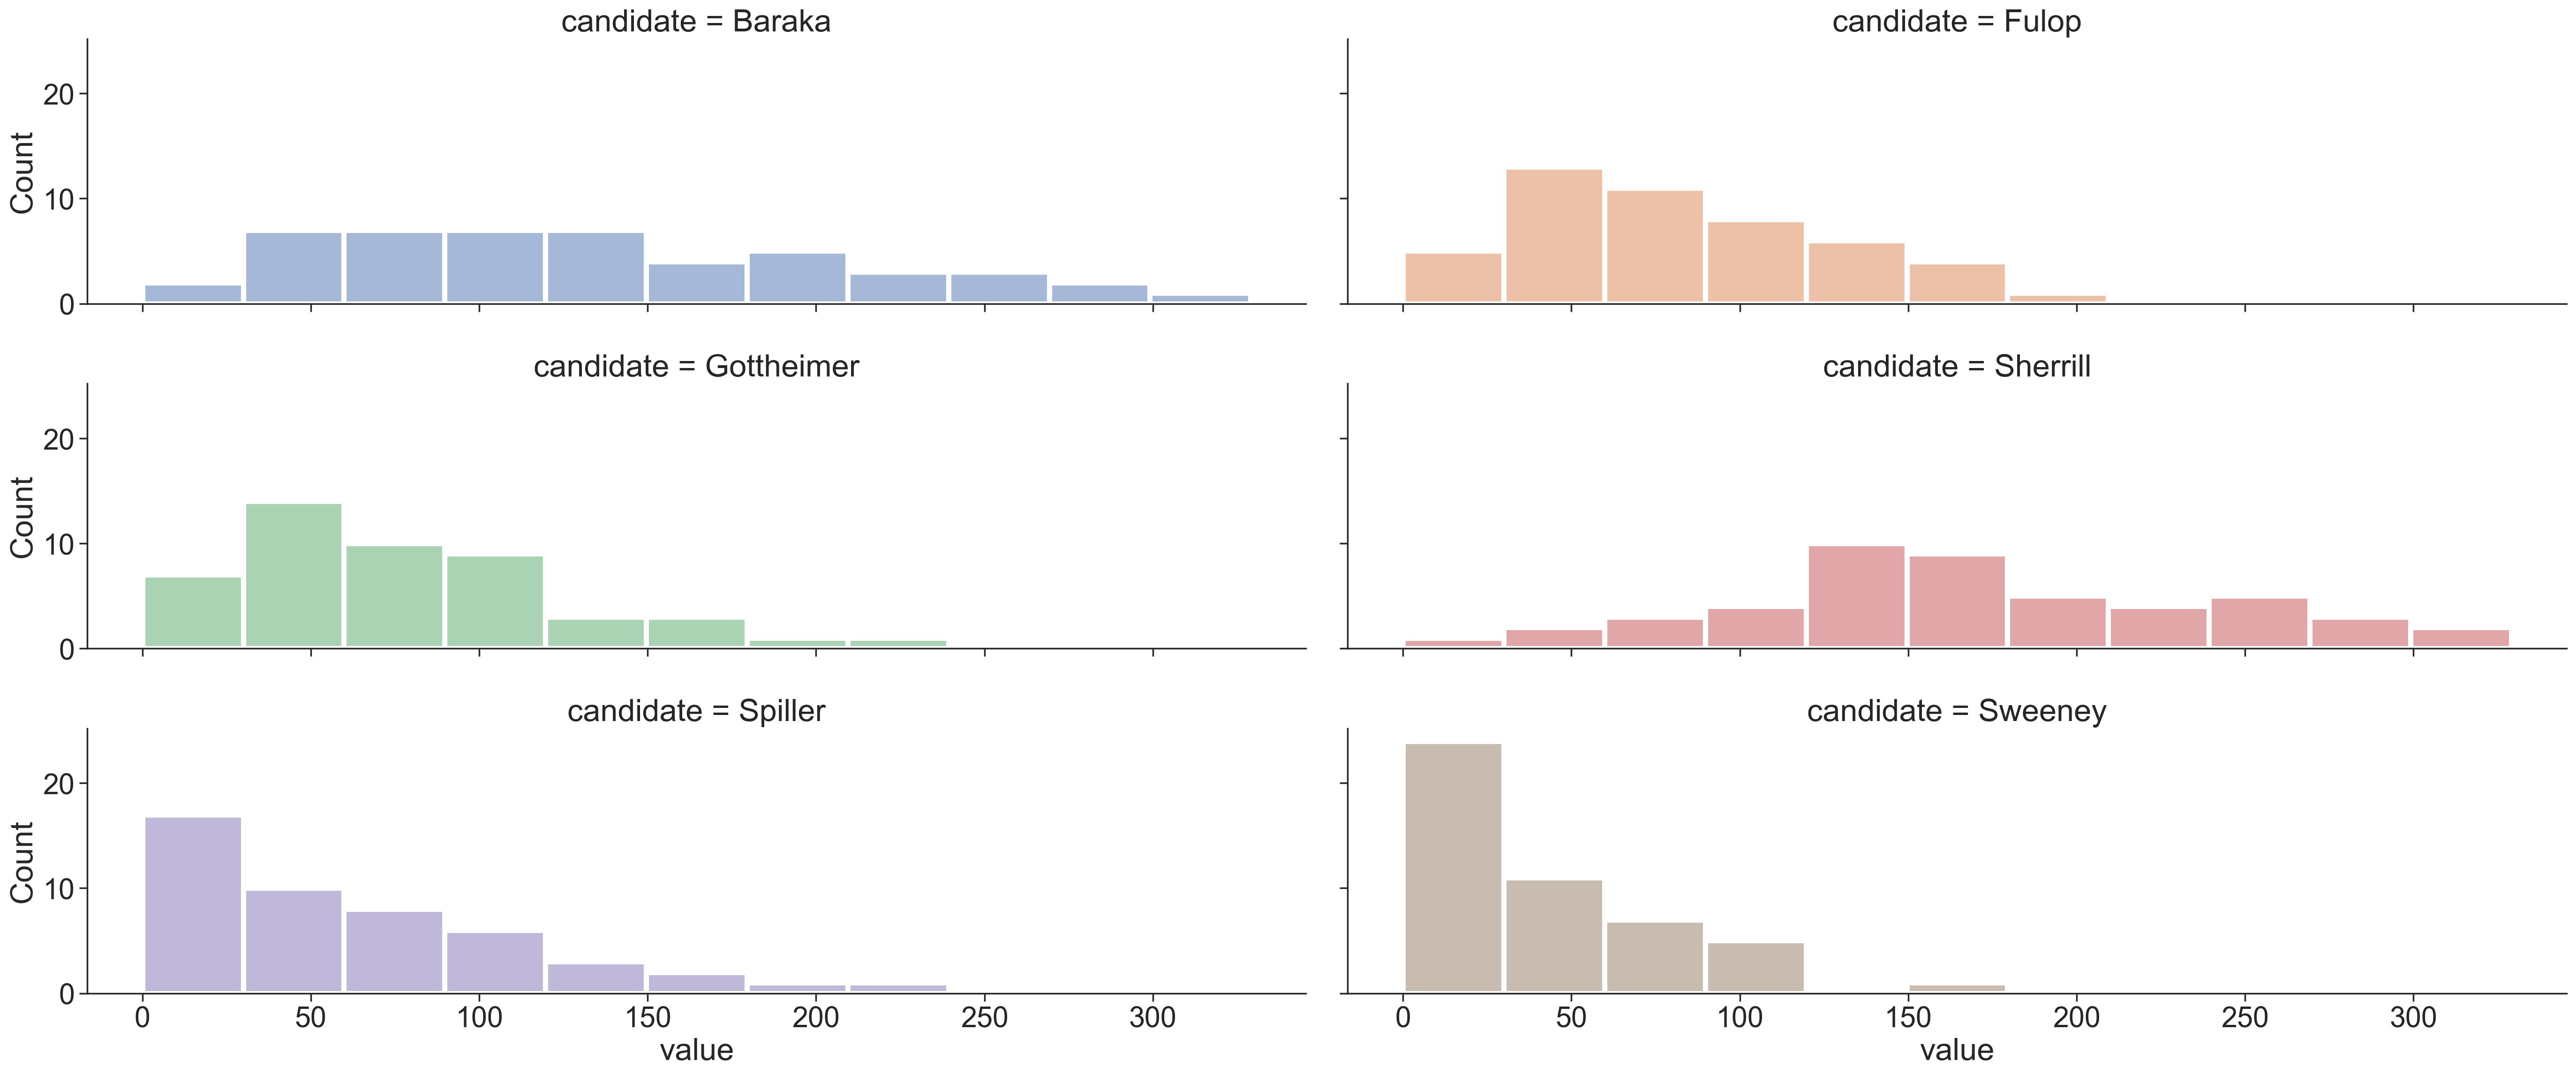

In [150]:
ax = sns.displot(data=for_plot[for_plot["candidate"] != "Undecided"], x="value", col="candidate", col_wrap=2,
                 hue="candidate", kind="hist", legend=False, aspect=3.5, height=4, linewidth=4)
plt.tight_layout()

In [151]:
df["mode"].value_counts()

mode
unknown                    42
text-to-web                28
phone/text-to-web          14
voterfile                  14
panel                       7
phone/text-to-web/panel     7
Name: count, dtype: int64

In [152]:
df["population"].value_counts()

population
lv     84
rv     21
vap     7
Name: count, dtype: int64

In [153]:
df["partisan"].value_counts()

partisan
0           28
Sherrill    28
Baraka      28
Spiller     28
Name: count, dtype: int64

---

In [154]:
# based on https://alexandorra.github.io/pollsposition_blog/popularity/macron/hidden%20markov%20models/polls/2021/05/16/hmm-popularity.html

In [155]:
df = df.melt(id_vars=[c for c in df.columns if not c.startswith("num_for")])
df = df.rename(columns={"value" : "num_for"})

# Non-Partisan Polls Only

In [156]:
np_df = df[df["partisan"] == "0"].copy()

In [157]:
month_id, months = np_df["end_date"].dt.to_period("M").factorize(sort=False)
months = [str(m) for m in months]

In [158]:
cand_id, candidates = np_df["candidate"].factorize(sort=False)

In [159]:
coords = {
    "observation" : np_df.index,
    "candidate" : candidates,
    "month" : months,
}

In [160]:
with pm.Model(coords=coords) as model:
    month_effect = pm.Normal("month_effect", 0, 0.15, dims="month")
    shrinkage_pop = pm.HalfNormal("shrinkage_pop", 0.2)
    cand_effect = pm.Normal("candidate_effect", mu=0, sigma=shrinkage_pop, dims="candidate")

    popularity = pm.math.invlogit(month_effect[month_id] + cand_effect[cand_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=np_df["sample_size"],
        observed=np_df["num_for"],
        dims="observation",
    )

In [161]:
with model:
    idata = pm.sample(extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [month_effect, shrinkage_pop, candidate_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


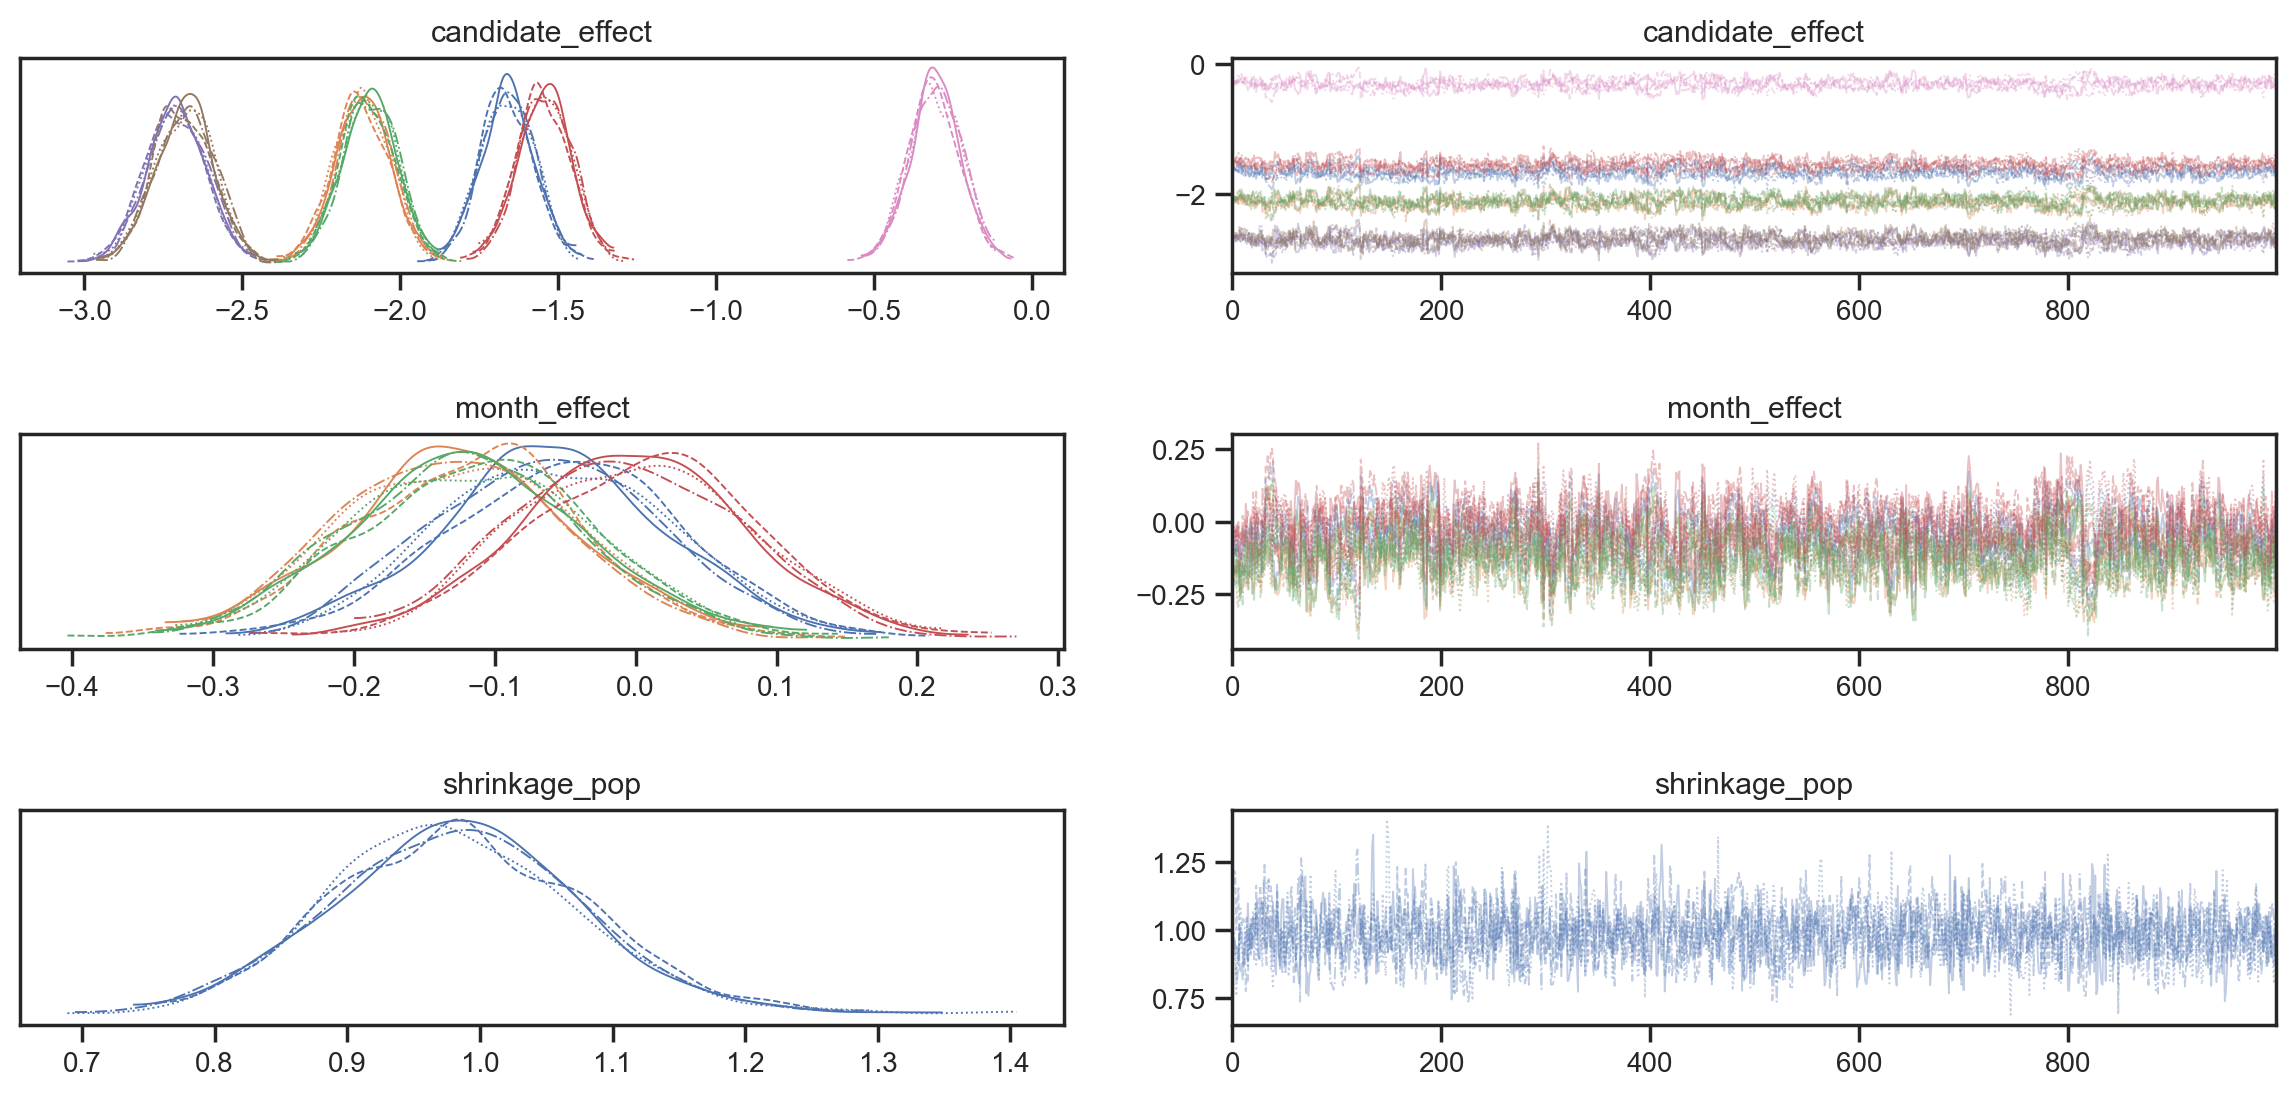

In [162]:
az.plot_trace(idata);
plt.tight_layout()

In [163]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [164]:
cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["month_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    cand_preds[str(c.values)] = post_pop.mean(axis=0)

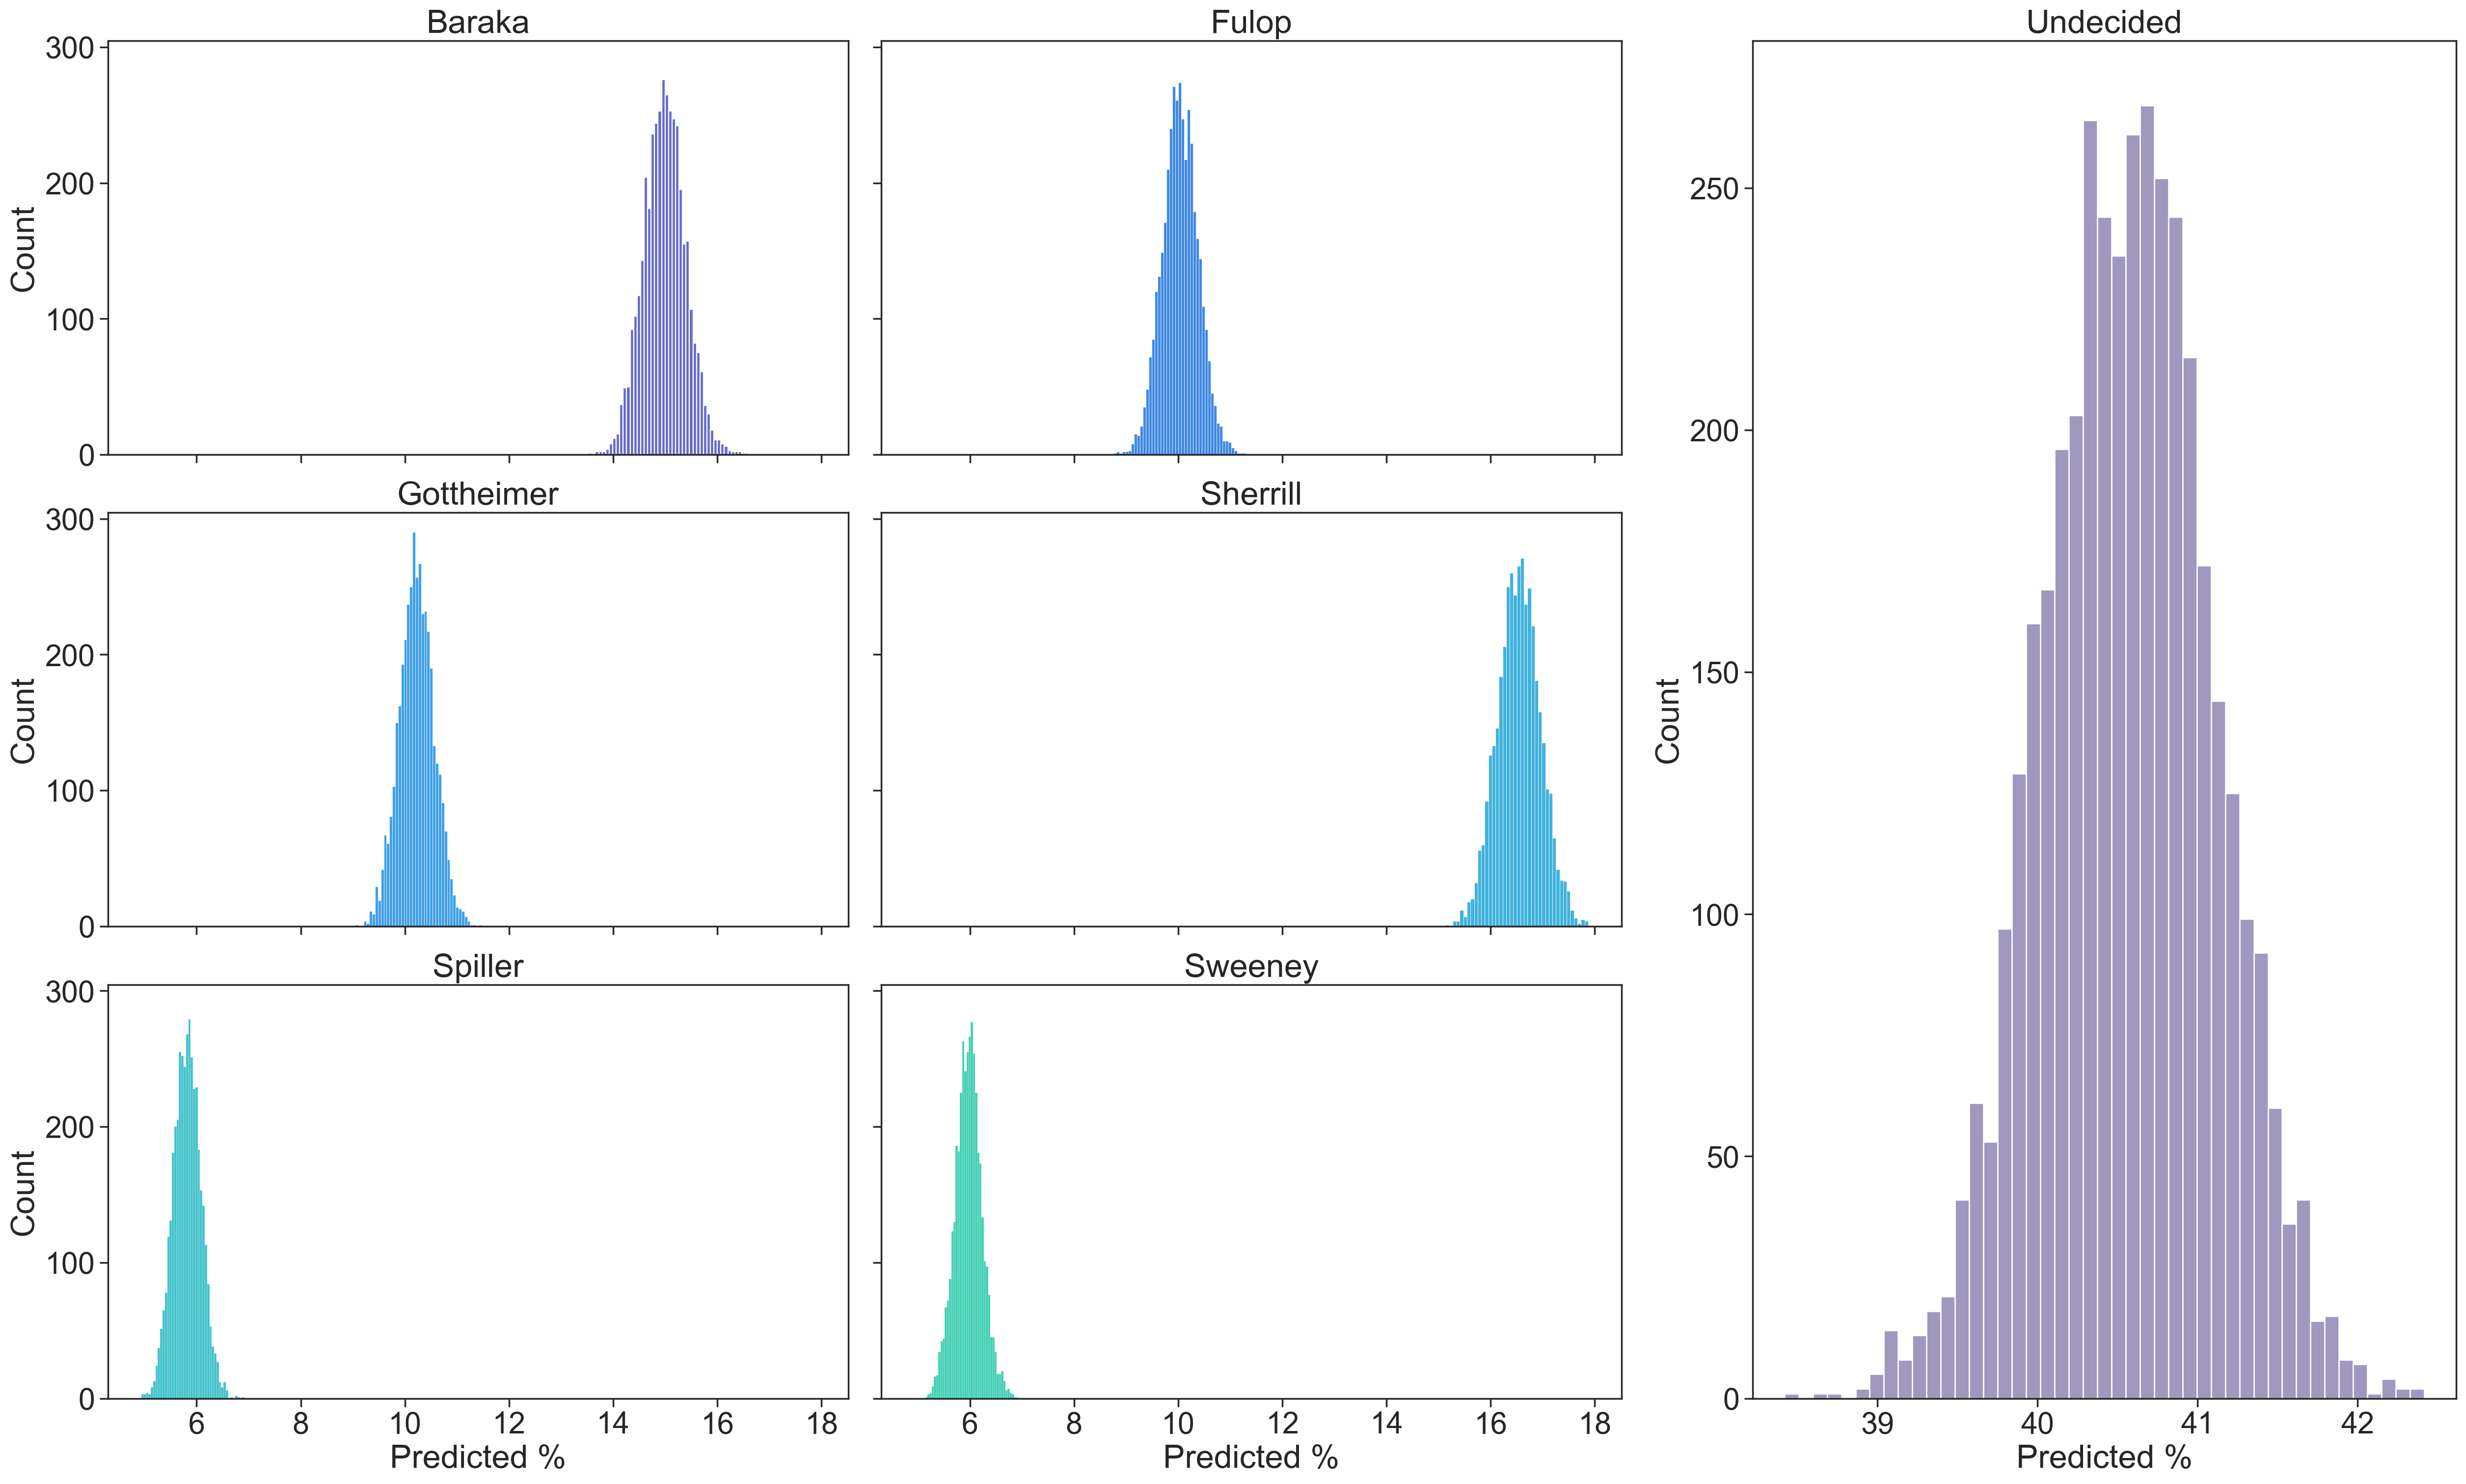

In [165]:
fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(1, 2, width_ratios=[2, 1])

axs = subfigs[0].subplots(3, 2, sharex=True, sharey=True)
colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]

for ((cand, ax), color) in zip(zip(cand_preds, axs.ravel()), colors):
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=color)
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")

ax = subfigs[1].subplots(1, 1)
sns.histplot(x=cand_preds["Undecided"] * 100, color="#8076a9", ax=ax)
ax.set_title("Undecided")
ax.set_xlabel("Predicted %")

plt.show()

In [166]:
rows = []
for cand in cand_preds:
    row = {"Candidate" : cand,
           "Pred" : np.mean(cand_preds[cand].values),
           "Lower" : np.quantile(cand_preds[cand], 0.025),
           "Upper" : np.quantile(cand_preds[cand], 0.975)}
    rows.append(row)
pred_df = pandas.DataFrame(rows)

In [167]:
pred_df.sort_values(by=["Pred"], ascending=False)

,Candidate,Pred,Lower,Upper
6,Undecided,0.405642,0.395198,0.416106
3,Sherrill,0.165405,0.157577,0.173649
0,Baraka,0.149931,0.142189,0.157856
2,Gottheimer,0.102230,0.095771,0.108790
1,Fulop,0.100315,0.093698,0.107029
5,Sweeney,0.059727,0.054490,0.065017
4,Spiller,0.058161,0.053044,0.063398


# All Polls (Including Partisan)

In [168]:
cand_id, candidates = df["candidate"].factorize(sort=False)

In [169]:
# kind_id, kinds = df["kind"].factorize(sort=False)

In [170]:
partisan_id, partisans = df["partisan"].factorize(sort=False)

In [171]:
month_id, months = df["end_date"].dt.to_period("M").factorize(sort=False)
months = [str(m) for m in months]

In [172]:
coords = {
    "observation" : df.index,
    "candidate" : candidates,
    "partisan" : partisans,
    "month" : months,
    # "kind" : kinds
}

In [173]:
with pm.Model(coords=coords) as model:
    partisan_effect = pm.Beta("partisan_effect", alpha=2, beta=5, dims="partisan")
    month_effect = pm.Normal("month_effect", 0, 0.15, dims="month")
    shrinkage_pop = pm.HalfNormal("shrinkage_pop", 0.2)
    cand_effect = pm.Normal("candidate_effect", mu=0, sigma=shrinkage_pop, dims="candidate")

    popularity = pm.math.invlogit(partisan_effect[partisan_id] + month_effect[month_id] + cand_effect[cand_id])

    y_hat = pm.Binomial(
        "y_hat",
        p=popularity,
        n=df["sample_size"],
        observed=df["num_for"],
        dims="observation",
    )

In [174]:
with model:
    idata = pm.sample(extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [partisan_effect, month_effect, shrinkage_pop, candidate_effect]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


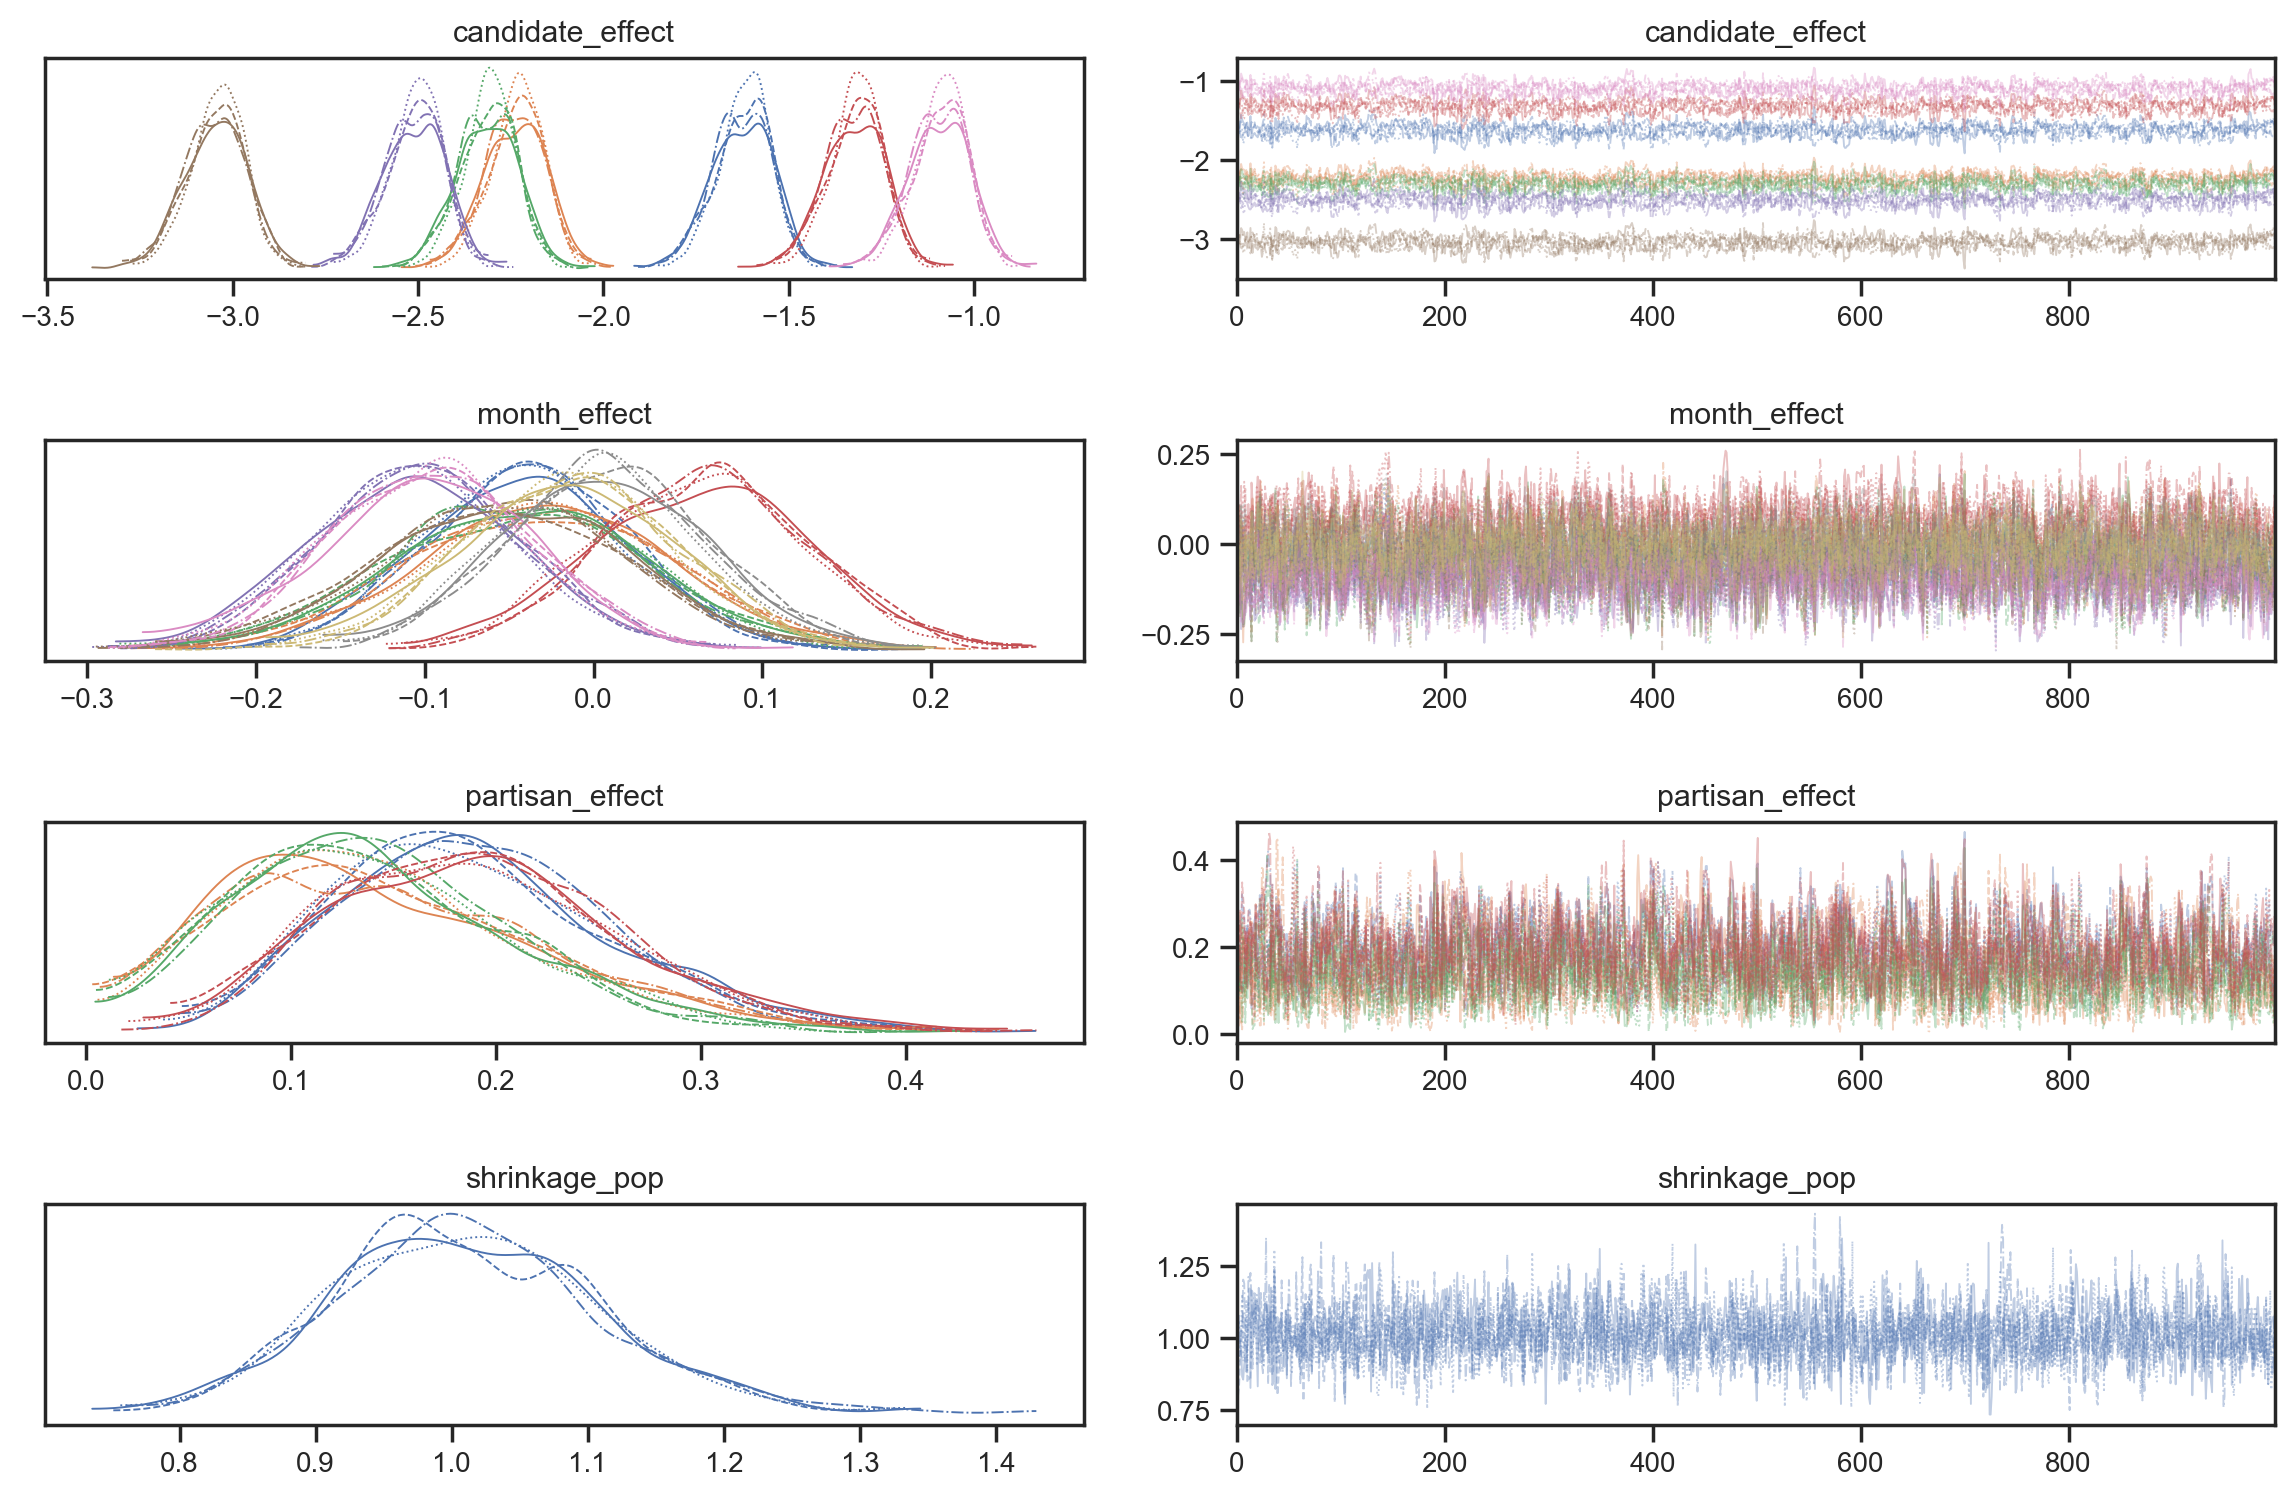

In [175]:
az.plot_trace(idata);
plt.tight_layout()

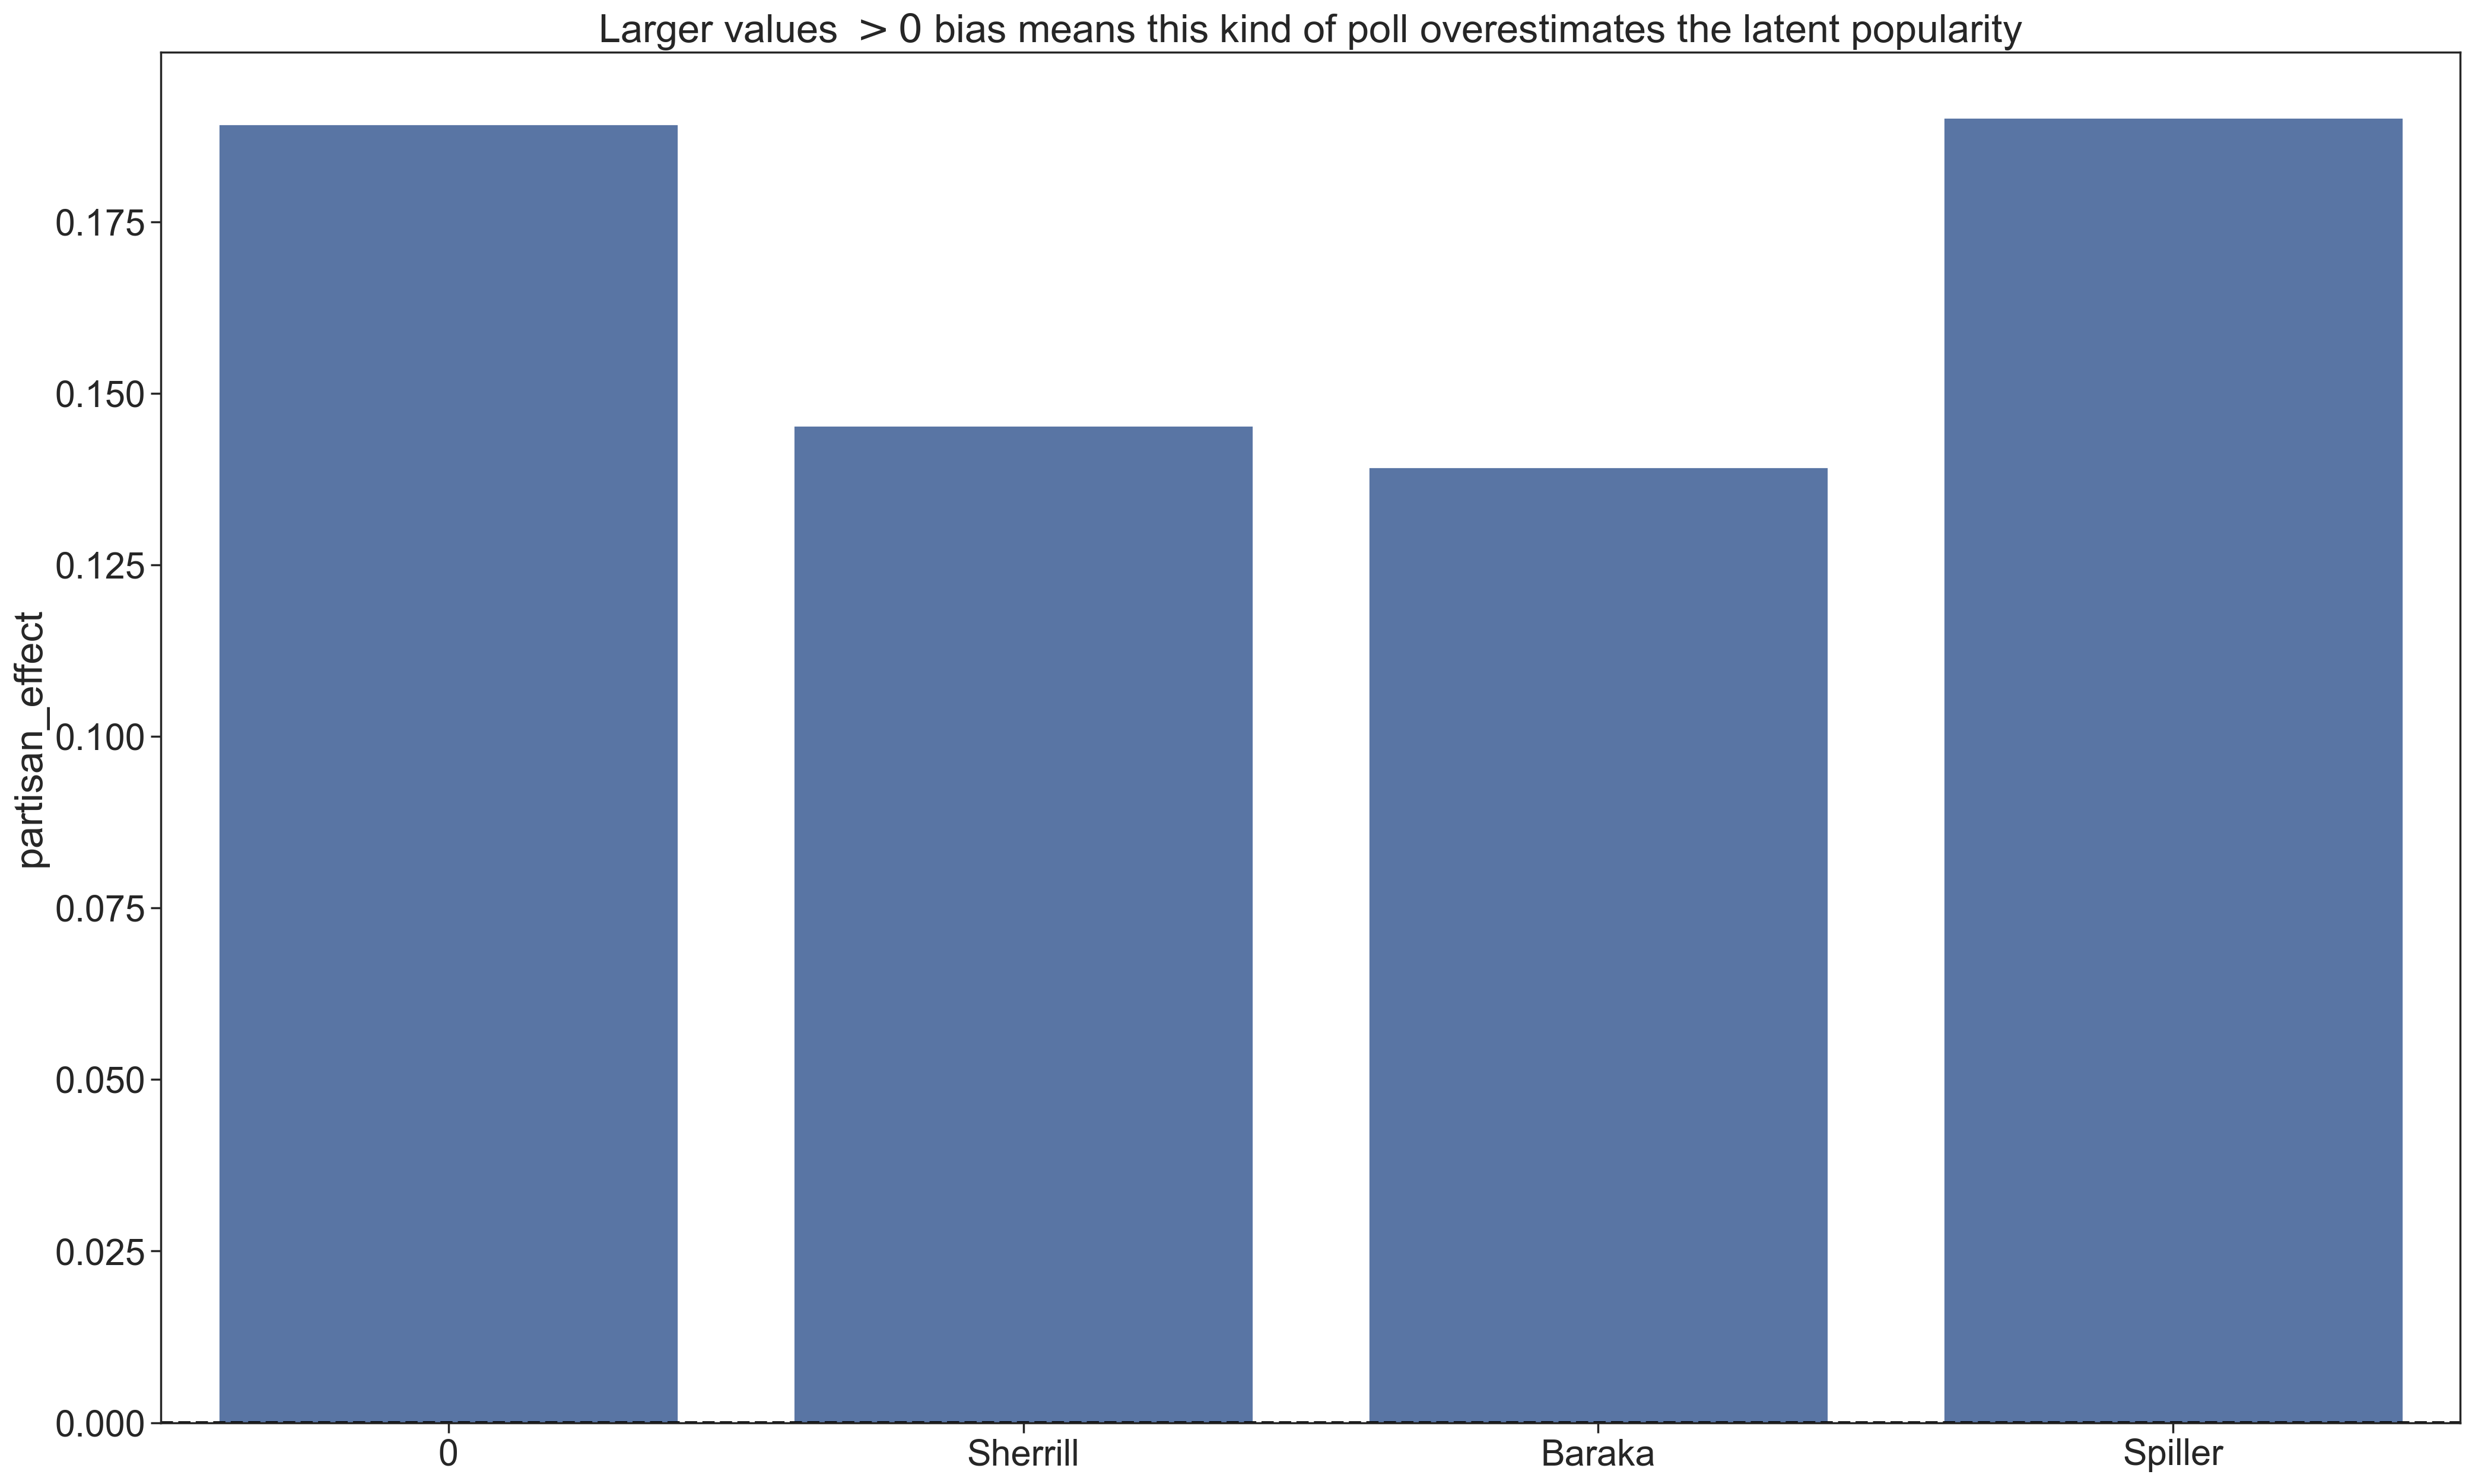

In [176]:
mean_kind_effect = (idata.posterior["partisan_effect"].mean(("chain", "draw")).to_dataframe()).reset_index()
ax = sns.barplot(data=mean_kind_effect, x="partisan", y="partisan_effect")
ax.axhline(0, color="black", linestyle="--", linewidth=2)
ax.set_title("Larger values $>0$ bias means this kind of poll overestimates the latent popularity")
ax.set_xlabel(None)
plt.show()

In [177]:
with model:
    pred_oos = pm.sample_posterior_predictive(idata, extend_inferencedata=True, predictions=True)

Sampling: [y_hat]


Output()

In [178]:
partisan_cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["partisan_effect"] +
                     post["month_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    partisan_cand_preds[str(c.values)] = dict(zip(post["partisan"].values, post_pop.mean(axis=1).values))

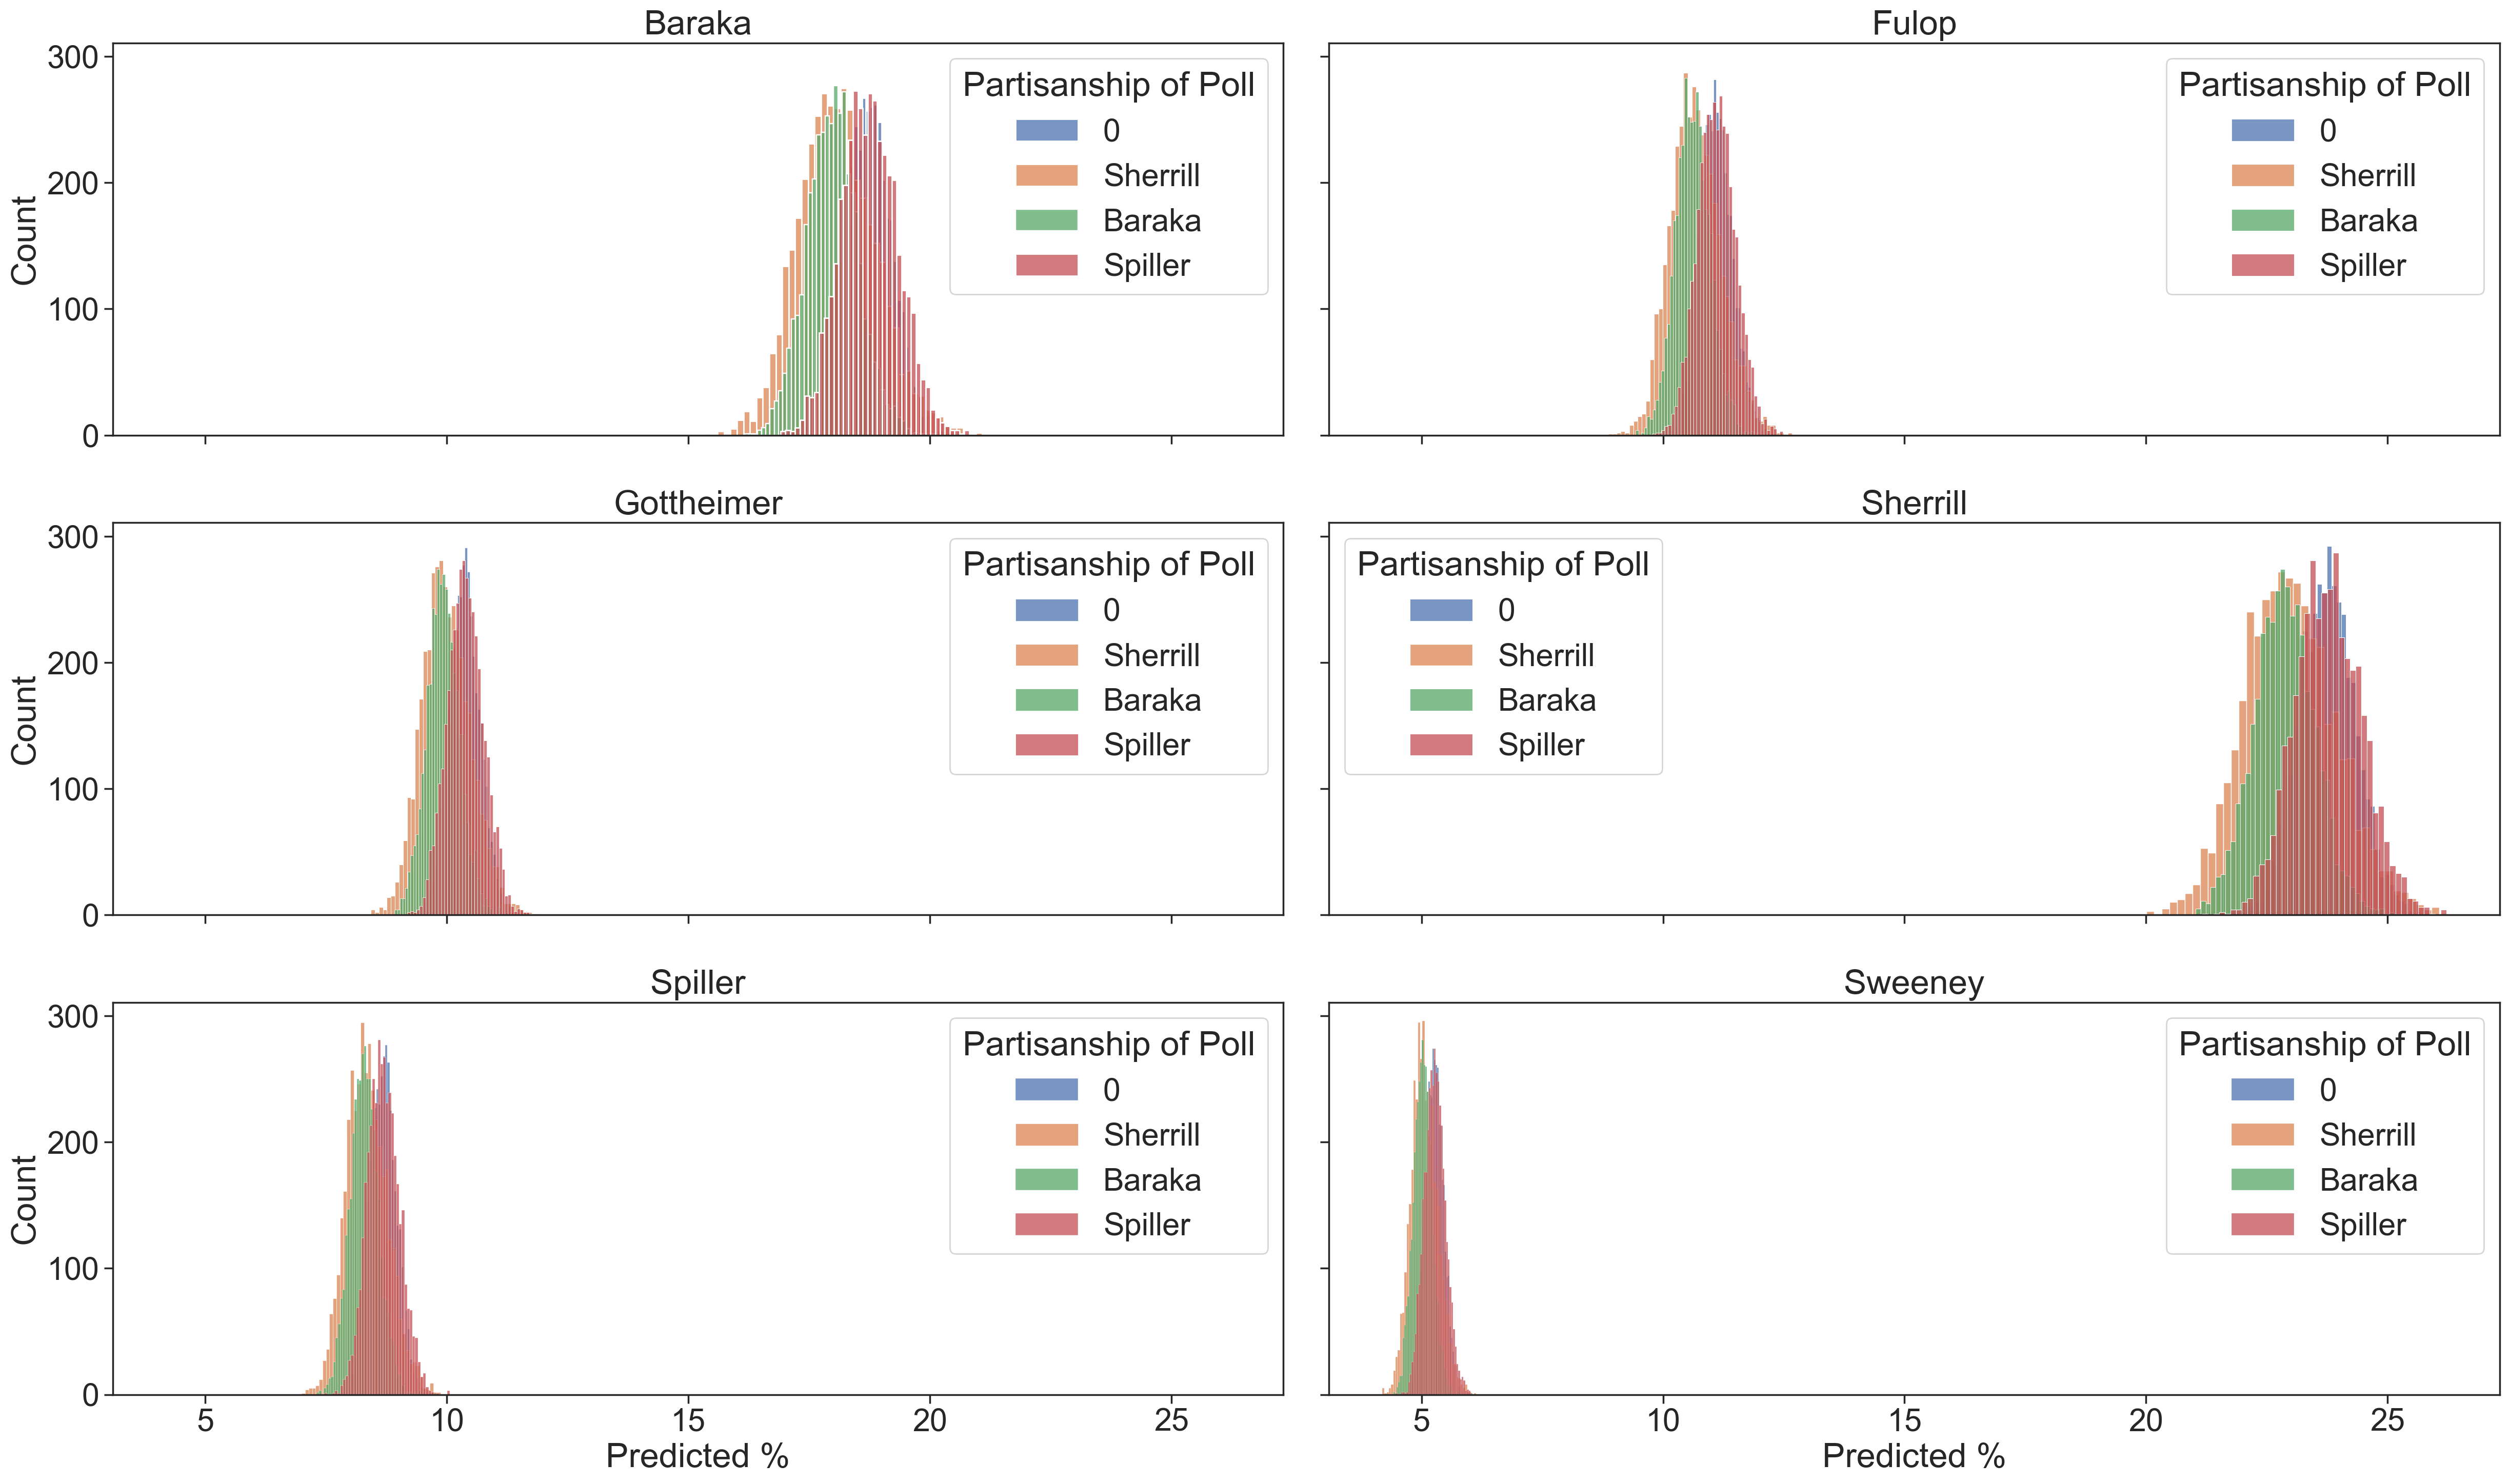

In [179]:
(fig, axs) = plt.subplots(3, 2, sharex=True, sharey=True)
for (cand, ax) in zip(partisan_cand_preds, axs.ravel()):
    for kind in partisan_cand_preds[cand]:
        sns.histplot(x=partisan_cand_preds[cand][kind] * 100, label=kind, ax=ax)
    ax.set_title(cand)
    ax.legend(title="Partisanship of Poll")
    ax.set_xlabel("Predicted %")

plt.tight_layout()

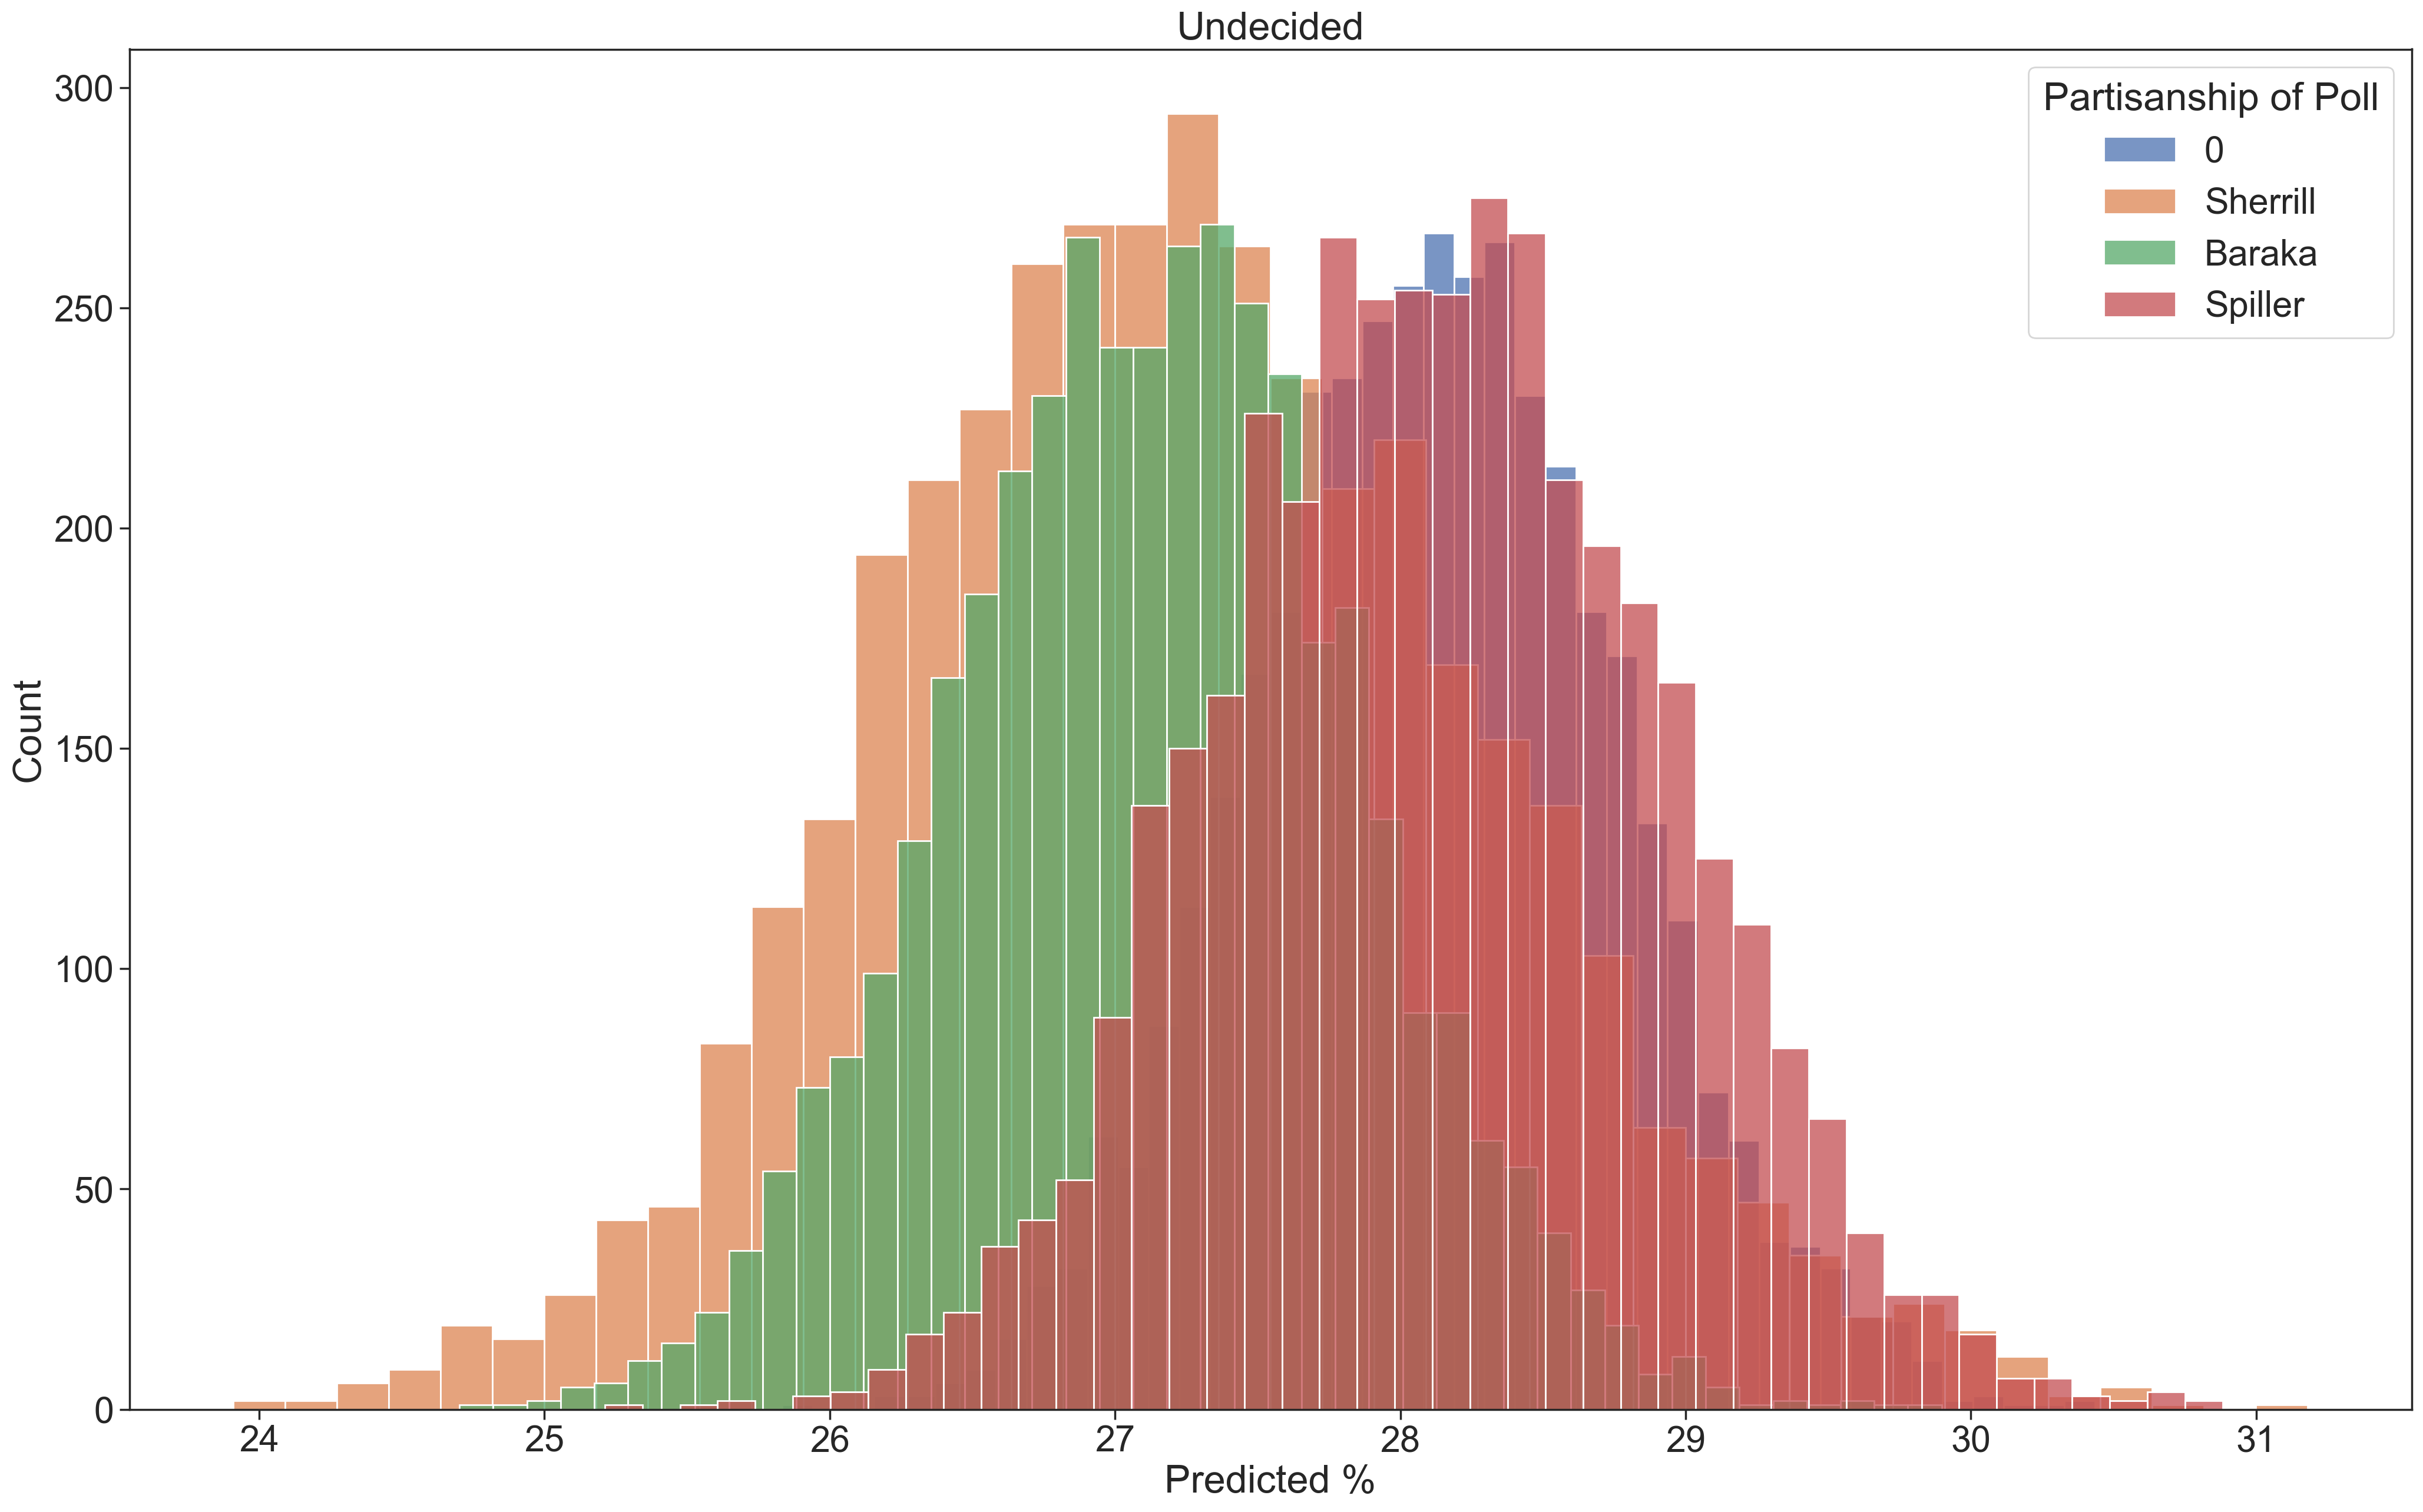

In [180]:
(fig, ax) = plt.subplots(1, 1)
for kind in partisan_cand_preds["Undecided"]:
    sns.histplot(x=partisan_cand_preds["Undecided"][kind] * 100, label=kind, ax=ax)
ax.set_title("Undecided")
ax.legend(title="Partisanship of Poll")
ax.set_xlabel("Predicted %")
plt.show()

In [181]:
partisan_cand_preds = {}

for c in idata.posterior.coords["candidate"]:
    post = idata.posterior.sel(candidate=c)
    post_pop = expit(post["partisan_effect"] +
                     post["month_effect"] +
                     post["candidate_effect"]).stack(sample=("chain", "draw"))
    partisan_cand_preds[str(c.values)] = post_pop.mean(axis=(0, 1))

In [182]:
rows = []
for cand in partisan_cand_preds:
    row = {"Candidate" : cand,
           "Pred" : np.mean(partisan_cand_preds[cand].values),
           "Lower" : np.quantile(partisan_cand_preds[cand], 0.025),
           "Upper" : np.quantile(partisan_cand_preds[cand], 0.975)}
    rows.append(row)
pred_df = pandas.DataFrame(rows)

In [183]:
pred_df.sort_values(by=["Pred"], ascending=False)

,Candidate,Pred,Lower,Upper
6,Undecided,0.276726,0.271309,0.282536
3,Sherrill,0.233400,0.228233,0.238548
0,Baraka,0.183863,0.179384,0.188528
1,Fulop,0.108741,0.105297,0.112228
2,Gottheimer,0.101680,0.098438,0.105175
4,Spiller,0.085056,0.081952,0.088330
5,Sweeney,0.051604,0.049261,0.054022


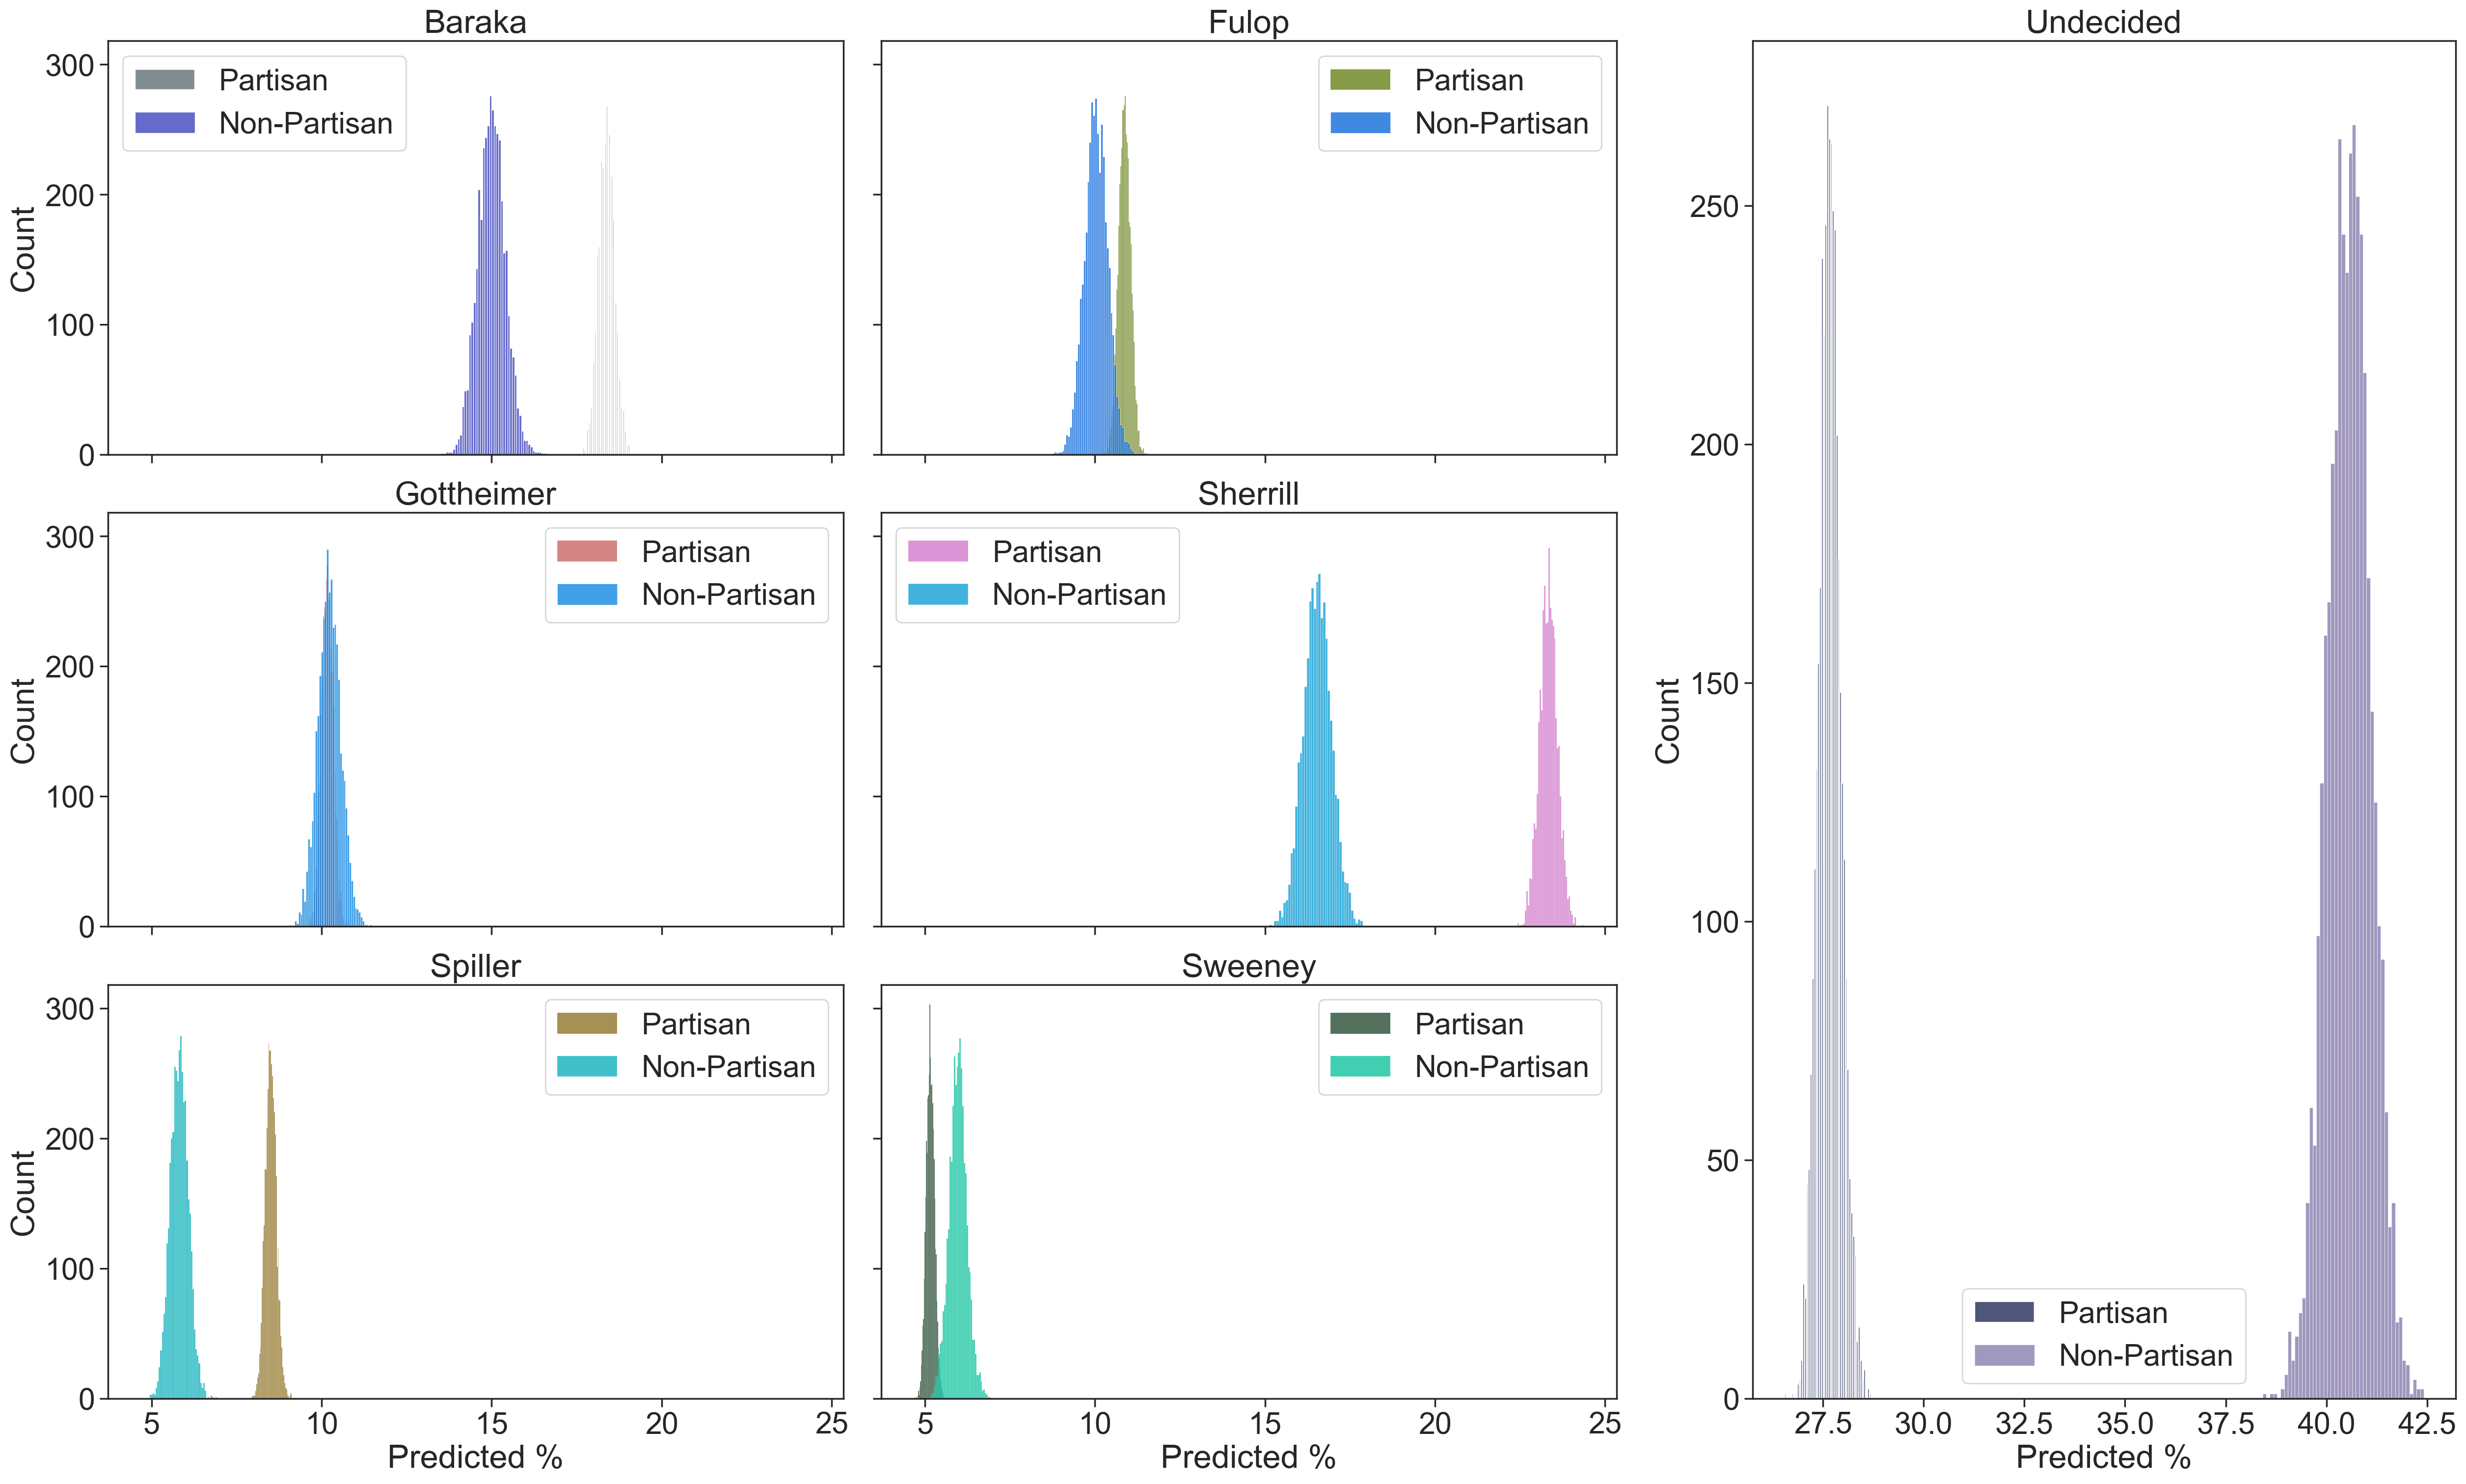

In [184]:
fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(1, 2, width_ratios=[2, 1])

axs = subfigs[0].subplots(3, 2, sharex=True, sharey=True)
np_colors = ["#323ab9", "#0062da", "#0080e1", "#0098d3", "#00adb7", "#00c097"]
p_colors = ["#56696C", "#5E790B", "#C85C5B", "#D071C9", "#886D1B", "#1B4127"]

for (i, (cand, ax)) in enumerate(zip(partisan_cand_preds, axs.ravel())):
    sns.histplot(x=partisan_cand_preds[cand] * 100, ax=ax, color=p_colors[i], label="Partisan")
    sns.histplot(x=cand_preds[cand] * 100, ax=ax, color=np_colors[i], label="Non-Partisan")
    ax.set_title(cand)
    ax.set_xlabel("Predicted %")
    ax.legend()

ax = subfigs[1].subplots(1, 1)
sns.histplot(x=partisan_cand_preds["Undecided"] * 100, color="#121D4E", ax=ax, label="Partisan")
sns.histplot(x=cand_preds["Undecided"] * 100, color="#8076a9", ax=ax, label="Non-Partisan")
ax.set_title("Undecided")
ax.set_xlabel("Predicted %")
ax.legend()

plt.show()